## IMPORTANDO VARIÁVEIS

In [2]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from hmmlearn import hmm
from sklearn.metrics import accuracy_score, confusion_matrix
from itertools import product
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np


load_dotenv()

True

In [56]:
# Carregar variáveis de ambiente
load_dotenv()

path_dados_tratados = os.getenv('PATH_DADOS_TRATADOS')

resultado_bruto = pd.read_csv(f"{path_dados_tratados}resultado_bruto.csv", index_col=0, parse_dates=True)
lucro_consolidado = pd.read_csv(f"{path_dados_tratados}lucro_consolidado.csv", index_col=0, parse_dates=True)
despesas_operacionais = pd.read_csv(f"{path_dados_tratados}despesas_operacionais.csv", index_col=0, parse_dates=True)
input_receita = {}
exog_vars_estac_lags = {}
dados_indices = {}
for empresa in resultado_bruto.columns:
    input_receita[empresa] = pd.read_csv(f"{path_dados_tratados}input_receita_{empresa}.csv", index_col=0, parse_dates=True)
    input_receita[empresa].index = pd.to_datetime(input_receita[empresa].index, format='%Y-%m-%d')
    exog_vars_estac_lags[empresa] = pd.read_csv(f"{path_dados_tratados}exog_vars_estac_lags_{empresa}.csv", index_col=0, parse_dates=True)
    exog_vars_estac_lags[empresa].index = pd.to_datetime(exog_vars_estac_lags[empresa].index, format='%Y-%m-%d')
    dados_indices[empresa] = pd.read_csv(f"{path_dados_tratados}dados_indices.csv", index_col=1, parse_dates=True, sep=';')
    dados_indices[empresa].drop(columns=['Unnamed: 0'], inplace=True)

## Teste PoissonHMM

ANÁLISE INDIVIDUAL

DIAGNÓSTICO DE ADEQUAÇÃO PARA POISSON HMM

Série: Resultado Bruto - Empresa 18376
Observações: 58

--- Estatísticas Descritivas ---
Média:           0.0241
Variância:       0.4338
Desvio Padrão:   0.6586

--- Teste de Dispersão ---
Índice de Dispersão (Var/Média): 18.0330
Classificação:   SOBREDISPERSÃO SEVERA

--- Verificações Adicionais ---
Contém valores negativos: SIM
Contém valores decimais:  SIM

--- Conclusão ---
Adequado para PoissonHMM: ✗ NÃO
Recomendação: CategoricalHMM ou GaussianHMM (dados não são contagens inteiras não-negativas)

ANÁLISE COMPARATIVA - RESULTADO BRUTO (MÚLTIPLAS EMPRESAS)

DIAGNÓSTICO DE ADEQUAÇÃO PARA POISSON HMM

Série: Empresa 21490
Observações: 58

--- Estatísticas Descritivas ---
Média:           0.0205
Variância:       0.0740
Desvio Padrão:   0.2721

--- Teste de Dispersão ---
Índice de Dispersão (Var/Média): 3.6033
Classificação:   SOBREDISPERSÃO MODERADA

--- Verificações Adicionais ---
Contém valores negativos: SIM
Contém valor

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,nome,media,variancia,indice_dispersao,dispersao_tipo,adequado_poisson,recomendacao
0,Empresa 21490,0.020542,0.074020,3.603319,SOBREDISPERSÃO MODERADA,False,CategoricalHMM ou GaussianHMM (dados não são c...
1,Empresa 2437,0.016242,0.142049,8.746037,SOBREDISPERSÃO SEVERA,False,CategoricalHMM ou GaussianHMM (dados não são c...
2,Empresa 20257,0.030880,0.173889,5.631196,SOBREDISPERSÃO SEVERA,False,CategoricalHMM ou GaussianHMM (dados não são c...
3,Empresa 18376,0.024056,0.433811,18.033030,SOBREDISPERSÃO SEVERA,False,CategoricalHMM ou GaussianHMM (dados não são c...



ANÁLISE COMPARATIVA - INDICADORES DA MESMA EMPRESA

DIAGNÓSTICO DE ADEQUAÇÃO PARA POISSON HMM

Série: Resultado Bruto
Observações: 58

--- Estatísticas Descritivas ---
Média:           0.0205
Variância:       0.0740
Desvio Padrão:   0.2721

--- Teste de Dispersão ---
Índice de Dispersão (Var/Média): 3.6033
Classificação:   SOBREDISPERSÃO MODERADA

--- Verificações Adicionais ---
Contém valores negativos: SIM
Contém valores decimais:  SIM

--- Conclusão ---
Adequado para PoissonHMM: ✗ NÃO
Recomendação: CategoricalHMM ou GaussianHMM (dados não são contagens inteiras não-negativas)

DIAGNÓSTICO DE ADEQUAÇÃO PARA POISSON HMM

Série: Lucro Consolidado
Observações: 58

--- Estatísticas Descritivas ---
Média:           0.0309
Variância:       0.2832
Desvio Padrão:   0.5321

--- Teste de Dispersão ---
Índice de Dispersão (Var/Média): 9.1614
Classificação:   SOBREDISPERSÃO SEVERA

--- Verificações Adicionais ---
Contém valores negativos: SIM
Contém valores decimais:  SIM

--- Conclusão ---
Ade

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,nome,media,variancia,indice_dispersao,dispersao_tipo,adequado_poisson,recomendacao
0,Resultado Bruto,0.020542,0.074020,3.603319,SOBREDISPERSÃO MODERADA,False,CategoricalHMM ou GaussianHMM (dados não são c...
1,Lucro Consolidado,0.030909,0.283168,9.161359,SOBREDISPERSÃO SEVERA,False,CategoricalHMM ou GaussianHMM (dados não são c...
2,Despesas Operacionais,-0.121198,NaN,NaN,INDEFINIDO,False,CategoricalHMM ou GaussianHMM (dados não são c...


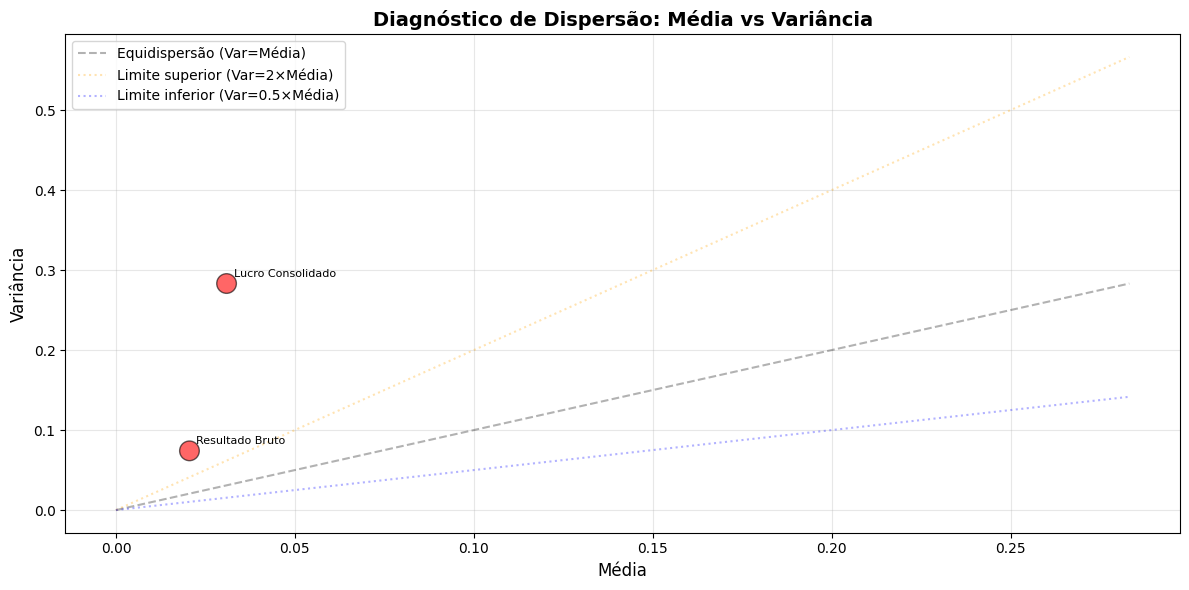

In [ ]:
def testar_adequacao_poisson(serie, nome_serie='Série'):
    """
    Testa se uma série temporal é adequada para distribuição Poisson.
    
    A distribuição Poisson assume que média ≈ variância (equidispersão).
    - Se variância >> média: sobredispersão (use Negative Binomial ou Categorical)
    - Se variância << média: subdispersão (menos comum, ainda use Categorical)
    - Se variância ≈ média: adequado para Poisson
    
    IMPORTANTE: A análise é feita sobre o LOG-RETURN de 1º grau da série,
    não sobre os valores originais.
    
    Args:
        serie: série temporal (pandas Series)
        nome_serie: nome descritivo da série
    
    Returns:
        dict com estatísticas e recomendação de modelo
    """
    # Prepara série original
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    # Calcula log-return de 1º grau: r_t = ln(p_t) - ln(p_{t-1})
    serie_log_return = np.log(serie_limpa).diff().dropna()
    
    # Calcula estatísticas sobre o LOG-RETURN
    media = serie_log_return.mean()
    variancia = serie_log_return.var()
    desvio_padrao = serie_log_return.std()
    
    # Índice de dispersão (variance-to-mean ratio)
    indice_dispersao = variancia / media if media != 0 else np.inf
    
    # Classificação
    if indice_dispersao > 5:
        dispersao_tipo = "SOBREDISPERSÃO SEVERA"
        recomendacao = "CategoricalHMM ou GaussianHMM"
        adequado_poisson = False
    elif indice_dispersao > 2:
        dispersao_tipo = "SOBREDISPERSÃO MODERADA"
        recomendacao = "CategoricalHMM (preferível)"
        adequado_poisson = False
    elif 0.5 <= indice_dispersao <= 2:
        dispersao_tipo = "EQUIDISPERSÃO"
        recomendacao = "PoissonHMM (adequado)"
        adequado_poisson = True
    elif indice_dispersao < 0.5:
        dispersao_tipo = "SUBDISPERSÃO"
        recomendacao = "CategoricalHMM"
        adequado_poisson = False
    else:
        dispersao_tipo = "INDEFINIDO"
        recomendacao = "CategoricalHMM (seguro)"
        adequado_poisson = False
    
    # Teste adicional: valores negativos (Poisson não suporta)
    tem_negativos = (serie_log_return < 0).any()
    tem_decimais = (serie_log_return % 1 != 0).any()
    
    if tem_negativos or tem_decimais:
        adequado_poisson = False
        recomendacao = "CategoricalHMM ou GaussianHMM (dados não são contagens inteiras não-negativas)"
    
    resultado = {
        'nome': nome_serie,
        'n_observacoes': len(serie_log_return),
        'media': media,
        'variancia': variancia,
        'desvio_padrao': desvio_padrao,
        'indice_dispersao': indice_dispersao,
        'dispersao_tipo': dispersao_tipo,
        'tem_negativos': tem_negativos,
        'tem_decimais': tem_decimais,
        'adequado_poisson': adequado_poisson,
        'recomendacao': recomendacao
    }
    
    return resultado

def exibir_diagnostico_poisson(resultado):
    """Exibe relatório formatado do diagnóstico"""
    print("\n" + "="*70)
    print(f"DIAGNÓSTICO DE ADEQUAÇÃO PARA POISSON HMM")
    print("="*70)
    print(f"\nSérie: {resultado['nome']}")
    print(f"Observações: {resultado['n_observacoes']}")
    print(f"\n--- Estatísticas Descritivas ---")
    print(f"Média:           {resultado['media']:.4f}")
    print(f"Variância:       {resultado['variancia']:.4f}")
    print(f"Desvio Padrão:   {resultado['desvio_padrao']:.4f}")
    print(f"\n--- Teste de Dispersão ---")
    print(f"Índice de Dispersão (Var/Média): {resultado['indice_dispersao']:.4f}")
    print(f"Classificação:   {resultado['dispersao_tipo']}")
    print(f"\n--- Verificações Adicionais ---")
    print(f"Contém valores negativos: {'SIM' if resultado['tem_negativos'] else 'NÃO'}")
    print(f"Contém valores decimais:  {'SIM' if resultado['tem_decimais'] else 'NÃO'}")
    print(f"\n--- Conclusão ---")
    print(f"Adequado para PoissonHMM: {'✓ SIM' if resultado['adequado_poisson'] else '✗ NÃO'}")
    print(f"Recomendação: {resultado['recomendacao']}")
    print("="*70)

def analisar_multiplas_series_poisson(series_dict):
    """
    Analisa múltiplas séries e retorna DataFrame comparativo.
    
    Args:
        series_dict: dicionário {'nome': serie_pandas}
    
    Returns:
        DataFrame com resultados comparativos
    """
    resultados = []
    
    for nome, serie in series_dict.items():
        resultado = testar_adequacao_poisson(serie, nome)
        resultados.append(resultado)
        exibir_diagnostico_poisson(resultado)
    
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# ==========================================
# EXEMPLO DE USO
# ==========================================

# Teste para uma empresa específica
print("="*70)
print("ANÁLISE INDIVIDUAL")
print("="*70)

empresa_teste = '18376'
resultado_rb = testar_adequacao_poisson(
    resultado_bruto[empresa_teste], 
    f'Resultado Bruto - Empresa {empresa_teste}'
)
exibir_diagnostico_poisson(resultado_rb)

# Teste para múltiplas empresas do mesmo indicador
print("\n" + "="*70)
print("ANÁLISE COMPARATIVA - RESULTADO BRUTO (MÚLTIPLAS EMPRESAS)")
print("="*70)

empresas_analise = ['21490', '2437', '20257', '18376']
series_rb = {
    f'Empresa {emp}': resultado_bruto[emp] 
    for emp in empresas_analise
}

df_comparativo_rb = analisar_multiplas_series_poisson(series_rb)

print("\n=== TABELA COMPARATIVA ===")
display(df_comparativo_rb[['nome', 'media', 'variancia', 'indice_dispersao', 
                            'dispersao_tipo', 'adequado_poisson', 'recomendacao']])

# Teste para múltiplos indicadores de uma empresa
print("\n" + "="*70)
print("ANÁLISE COMPARATIVA - INDICADORES DA MESMA EMPRESA")
print("="*70)

empresa_analise = '21490'
series_indicadores = {
    'Resultado Bruto': resultado_bruto[empresa_analise],
    'Lucro Consolidado': lucro_consolidado[empresa_analise],
    'Despesas Operacionais': despesas_operacionais[empresa_analise]
}

df_comparativo_ind = analisar_multiplas_series_poisson(series_indicadores)

print("\n=== TABELA COMPARATIVA ===")
display(df_comparativo_ind[['nome', 'media', 'variancia', 'indice_dispersao', 
                             'dispersao_tipo', 'adequado_poisson', 'recomendacao']])

# Visualização gráfica
def plotar_diagnostico_dispersao(df_resultados):
    """Plota gráfico de dispersão para análise visual"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    cores = ['green' if x else 'red' for x in df_resultados['adequado_poisson']]
    
    ax.scatter(df_resultados['media'], df_resultados['variancia'], 
               s=200, c=cores, alpha=0.6, edgecolors='black')
    
    # Linha de referência (média = variância)
    max_val = max(df_resultados['media'].max(), df_resultados['variancia'].max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equidispersion (Var=Mean)')
    
    # Tolerance lines
    ax.plot([0, max_val], [0, max_val*2], 'orange', alpha=0.3, linestyle=':', label='Upper limit (Var=2×Mean)')
    ax.plot([0, max_val], [0, max_val*0.5], 'blue', alpha=0.3, linestyle=':', label='Lower limit (Var=0.5×Mean)')
    
    # Anotações
    for idx, row in df_resultados.iterrows():
        ax.annotate(row['nome'], (row['media'], row['variancia']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Mean', fontsize=12)
    ax.set_ylabel('Variance', fontsize=12)
    ax.set_title('Dispersion Diagnostics: Mean vs Variance', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plota diagnóstico
plotar_diagnostico_dispersao(df_comparativo_ind)

## Categorical HMM

### K-means

In [5]:
def discretiza_kmeans(serie, bins, tipo_clusterizacao='quantile', tipo_discretizacao='log_returns'):
    # Usa retornos simples (pct_change) em vez de log-returns
    if tipo_discretizacao != 'log_returns':
        pct = (
            pd.Series(serie)
            .pct_change()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # Formato 2D para o discretizador
        X = pct.values.reshape(-1, 1)
        index_ajustado = pct.index
    else:
        log_returns = (
            np.log(pd.Series(serie))
            .diff()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        X = log_returns.values.reshape(-1, 1)
        index_ajustado = log_returns.index
    # K-means ou quantile conforme parâmetro
    est_kmeans = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=tipo_clusterizacao)
    X_discrete_kmeans = est_kmeans.fit_transform(X)

    print("Bordas dos Bins (K-Means):")
    print(est_kmeans.bin_edges_[0])

    df_resultado_kmeans = pd.DataFrame(
        X_discrete_kmeans,
        index=index_ajustado,
        columns=['estado_kmeans']
    )

    X_discrete_kmeans_1d = X_discrete_kmeans.astype(int)
    df_resultado_kmeans['estado_kmeans'] = df_resultado_kmeans['estado_kmeans'].astype(int)

    return X_discrete_kmeans_1d

In [6]:
dis = discretiza_kmeans(resultado_bruto['2437'], bins=3,tipo_discretizacao='log_returns')

Bordas dos Bins (K-Means):
[-1.34640617 -0.03940996  0.08500885  1.58786381]


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
def plotar_log_returns_clusters(serie, bins=3, nome_serie='Série', usar_log_returns=False, tipo_clusterizacao='kmeans'):
    """
    Plota série temporal com discretização de retornos via K-means/quantile.

    Args:
        serie: pandas Series original
        bins: número de clusters/bins
        nome_serie: rótulo para o gráfico
        usar_log_returns: True usa log-returns; False usa pct_change
        tipo_clusterizacao: estratégia do KBinsDiscretizer ('quantile', 'kmeans', 'uniform')
    """
    serie = pd.Series(serie)
    if usar_log_returns:
        retornos = np.log(serie).diff()
    else:
        retornos = serie.pct_change()

    retornos = retornos.replace([np.inf, -np.inf], np.nan).dropna()
    index_ajustado = retornos.index

    X = retornos.values.reshape(-1, 1)
    est = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=tipo_clusterizacao)
    X_discrete = est.fit_transform(X)
    clusters = X_discrete.flatten().astype(int)

    bordas = est.bin_edges_[0]
    cores_cluster = ['crimson', 'navy', 'darkgreen', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta']

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Série original
    ax1 = axes[0]
    ax1.plot(serie.index, serie, color='steelblue', linewidth=1.5, label='Original Series', alpha=0.8)
    ax1.set_title(f'{nome_serie} - Original Series', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Value', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Retornos com clusters
    ax2 = axes[1]
    ax2.plot(index_ajustado, retornos, color='gray', linewidth=1, alpha=0.5, label='Retornos', zorder=1)

    for cluster_id in range(bins):
        mascara = clusters == cluster_id
        ax2.scatter(index_ajustado[mascara], retornos.iloc[mascara],
                    c=cores_cluster[cluster_id % len(cores_cluster)],
                    s=50, alpha=0.7, label=f'Cluster {cluster_id}',
                    edgecolors='black', linewidths=0.5, zorder=2)

    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
    for i, borda in enumerate(bordas[1:-1], start=1):
        ax2.axhline(y=borda, color='red', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Boundary {i}' if i == 1 else '')

    eixo_label = 'Log-Returns' if usar_log_returns else 'Pct Change'
    ax2.set_title(f'{nome_serie} - {eixo_label} with Clusters ({bins} clusters)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=11)
    ax2.set_ylabel(eixo_label, fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left', fontsize=10, ncol=2)

    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # Exibe Estatísticas dos Clusters
    # ==========================================
    print(f"\n{'='*70}")
    print(f"ESTATÍSTICAS DOS CLUSTERS - {nome_serie}")
    print('='*70)
    print(f"\nNúmero de clusters: {bins}")
    print(f"\nBordas dos Bins (K-Means):")
    for i, borda in enumerate(bordas):
        print(f"  Borda {i}: {borda:.6f}")
    
    print(f"\nDistribuição dos Log-Returns por Cluster:")
    for cluster_id in range(bins):
        mascara = clusters == cluster_id
        valores_cluster = retornos.iloc[mascara]  # corrigido: usar 'retornos' definido acima

        print(f"\n  Cluster {cluster_id}:")
        print(f"    N° observações: {mascara.sum()} ({(mascara.sum()/len(clusters))*100:.1f}%)")
        print(f"    Média: {valores_cluster.mean():.6f}")
        print(f"    Mediana: {np.median(valores_cluster):.6f}")
        print(f"    Desvio Padrão: {valores_cluster.std():.6f}")
        print(f"    Min/Max: {valores_cluster.min():.6f} / {valores_cluster.max():.6f}")

    print('='*70)

    return {
        'log_returns': retornos,   # corrigido: retornar a série calculada
        'clusters': clusters,
        'index': index_ajustado,
        'bordas': bordas
    }


# ...existing code...
def plotar_comparacao_clusters_multiplas_series(series_dict, bins=3, tipo_clusterizacao='kmeans', usar_log_returns=False):
    """
    Plota comparação de clusters de múltiplas séries em uma única figura.

    Args:
        series_dict: dicionário {'nome_serie': serie_pandas}
        bins: número de clusters
        tipo_clusterizacao: estratégia do KBinsDiscretizer
        usar_log_returns: True usa log-returns; False usa pct_change
    """
    n_series = len(series_dict)
    fig, axes = plt.subplots(n_series, 1, figsize=(16, 5 * n_series))

    if n_series == 1:
        axes = [axes]

    cores_cluster = ['crimson', 'navy', 'darkgreen', 'purple', 'orange',
                     'brown', 'pink', 'gray', 'cyan', 'magenta']

    for idx, (nome_serie, serie) in enumerate(series_dict.items()):
        serie = pd.Series(serie)
        if usar_log_returns:
            retornos = np.log(serie).diff()
        else:
            retornos = serie.pct_change()

        retornos = retornos.replace([np.inf, -np.inf], np.nan).dropna()
        index_ajustado = retornos.index

        X = retornos.values.reshape(-1, 1)
        est_kmeans = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=tipo_clusterizacao)
        X_discrete = est_kmeans.fit_transform(X)
        clusters = X_discrete.flatten().astype(int)
        bordas = est_kmeans.bin_edges_[0]

        ax = axes[idx]
        ax.plot(index_ajustado, retornos, color='gray', linewidth=1,
                alpha=0.5, label='Log-Returns' if usar_log_returns else 'Pct Change', zorder=1)

        for cluster_id in range(bins):
            mascara = clusters == cluster_id
            ax.scatter(index_ajustado[mascara],
                      retornos.iloc[mascara],
                      c=cores_cluster[cluster_id % len(cores_cluster)],
                      s=50, alpha=0.7,
                      label=f'Cluster {cluster_id}',
                      edgecolors='black', linewidths=0.5,
                      zorder=2)

        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)

        for borda in bordas[1:-1]:
            ax.axhline(y=borda, color='red', linestyle=':', linewidth=1.5, alpha=0.6)

        eixo_label = 'Log-Returns' if usar_log_returns else 'Pct Change'
        ax.set_title(f'{nome_serie} - {eixo_label} with {bins} Clusters',
                    fontsize=12, fontweight='bold')
        ax.set_ylabel(eixo_label, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', fontsize=9, ncol=bins+1)

    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()
# ...existing code...
def plotar_histograma_clusters(serie, bins=3, nome_serie='Série', tipo_clusterizacao='kmeans', usar_log_returns=False):
    """
    Plota histograma dos retornos colorido por cluster.

    Args:
        serie: série temporal original
        bins: número de clusters
        nome_serie: nome da série
        tipo_clusterizacao: estratégia do KBinsDiscretizer
        usar_log_returns: True usa log-returns; False usa pct_change
    """
    serie = pd.Series(serie)
    if usar_log_returns:
        retornos = np.log(serie).diff()
    else:
        retornos = serie.pct_change()

    retornos = retornos.replace([np.inf, -np.inf], np.nan).dropna()

    X = retornos.values.reshape(-1, 1)
    est_kmeans = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=tipo_clusterizacao)
    X_discrete = est_kmeans.fit_transform(X)
    clusters = X_discrete.flatten().astype(int)
    bordas = est_kmeans.bin_edges_[0]

    cores_cluster = ['crimson', 'navy', 'darkgreen', 'purple', 'orange']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Histograma sobreposto
    ax1 = axes[0]
    for cluster_id in range(bins):
        mascara = clusters == cluster_id
        valores_cluster = retornos.iloc[mascara]
        ax1.hist(valores_cluster, bins=30, alpha=0.6,
                label=f'Cluster {cluster_id} (n={mascara.sum()})',
                color=cores_cluster[cluster_id % len(cores_cluster)],
                edgecolor='black', linewidth=0.5)

    for borda in bordas:
        ax1.axvline(x=borda, color='red', linestyle='--', linewidth=2, alpha=0.7)

    eixo_label = 'Log-Returns' if usar_log_returns else 'Pct Change'
    ax1.set_xlabel(eixo_label, fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title(f'{nome_serie} - Histogram by Cluster', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. Boxplot por cluster
    ax2 = axes[1]
    dados_boxplot = [retornos[clusters == i] for i in range(bins)]
    bp = ax2.boxplot(dados_boxplot,
                     labels=[f'Cluster {i}' for i in range(bins)],
                     patch_artist=True)

    for patch, cor in zip(bp['boxes'], cores_cluster):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax2.set_ylabel(eixo_label, fontsize=11)
    ax2.set_title(f'{nome_serie} - Boxplot by Cluster', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
# ...existing code...

# ==========================================
# EXEMPLOS DE USO
# ==========================================





ANÁLISE DE CLUSTERS - EMPRESA INDIVIDUAL


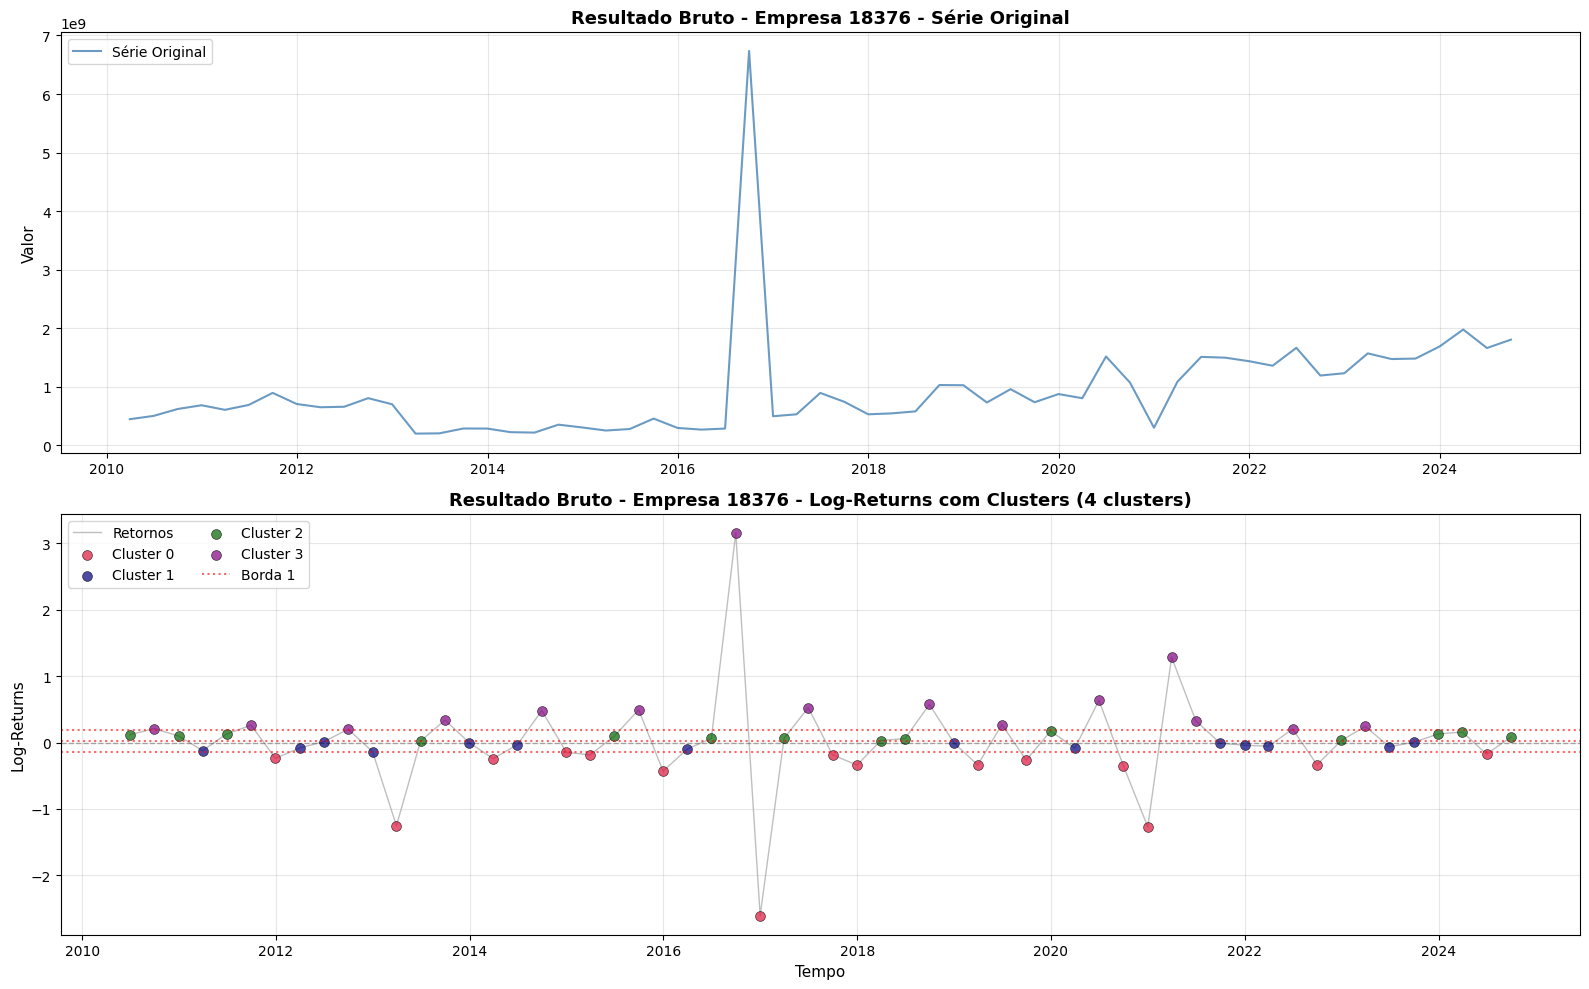


ESTATÍSTICAS DOS CLUSTERS - Resultado Bruto - Empresa 18376

Número de clusters: 4

Bordas dos Bins (K-Means):
  Borda 0: -2.604800
  Borda 1: -0.144766
  Borda 2: 0.017272
  Borda 3: 0.193948
  Borda 4: 3.155656

Distribuição dos Log-Returns por Cluster:

  Cluster 0:
    N° observações: 15 (25.9%)
    Média: -0.556754
    Mediana: -0.334236
    Desvio Padrão: 0.668958
    Min/Max: -2.604800 / -0.146976

  Cluster 1:
    N° observações: 14 (24.1%)
    Média: -0.050831
    Mediana: -0.048189
    Desvio Padrão: 0.048724
    Min/Max: -0.138136 / 0.012277

  Cluster 2:
    N° observações: 14 (24.1%)
    Média: 0.089719
    Mediana: 0.089015
    Desvio Padrão: 0.047661
    Min/Max: 0.022268 / 0.173289

  Cluster 3:
    N° observações: 15 (25.9%)
    Média: 0.613477
    Mediana: 0.338443
    Desvio Padrão: 0.755528
    Min/Max: 0.200834 / 3.155656


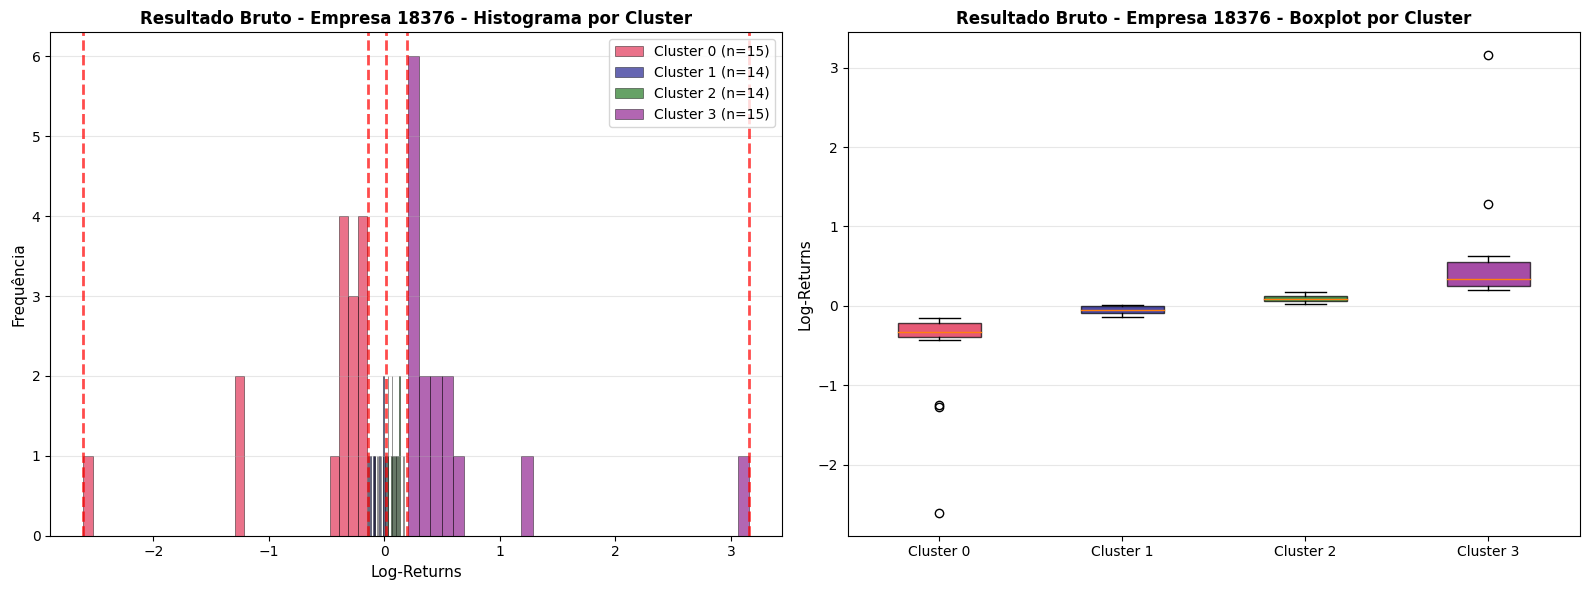


COMPARAÇÃO DE CLUSTERS - MÚLTIPLAS EMPRESAS


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


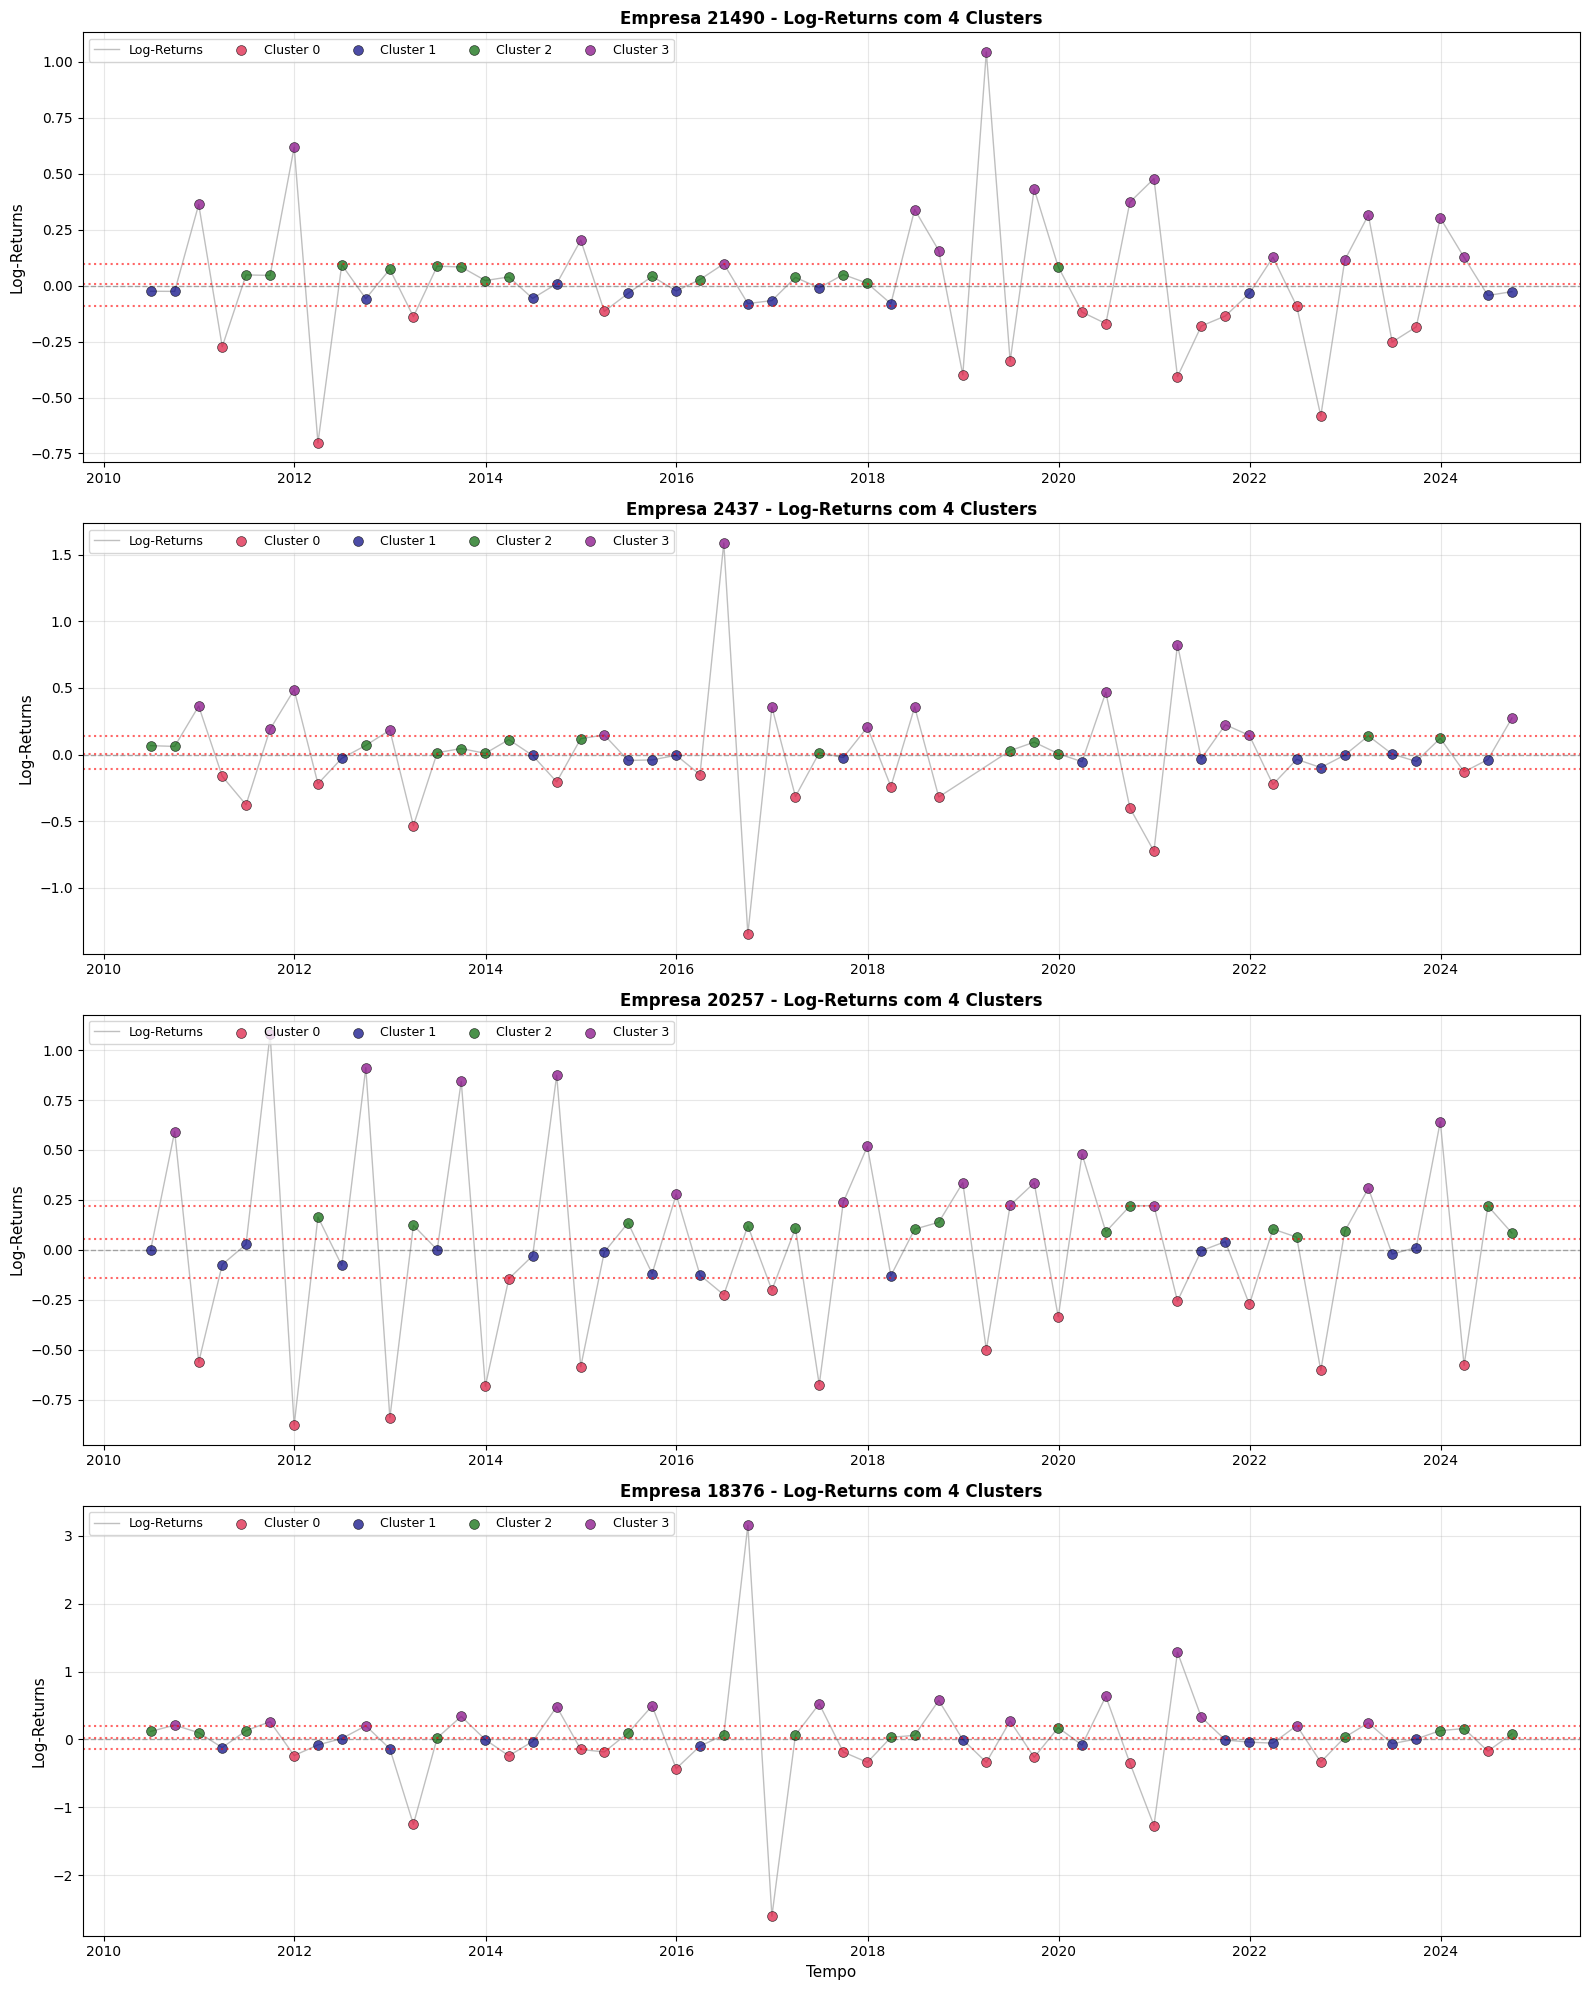


TESTE COM DIFERENTES NÚMEROS DE CLUSTERS

--- 3 Clusters ---


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


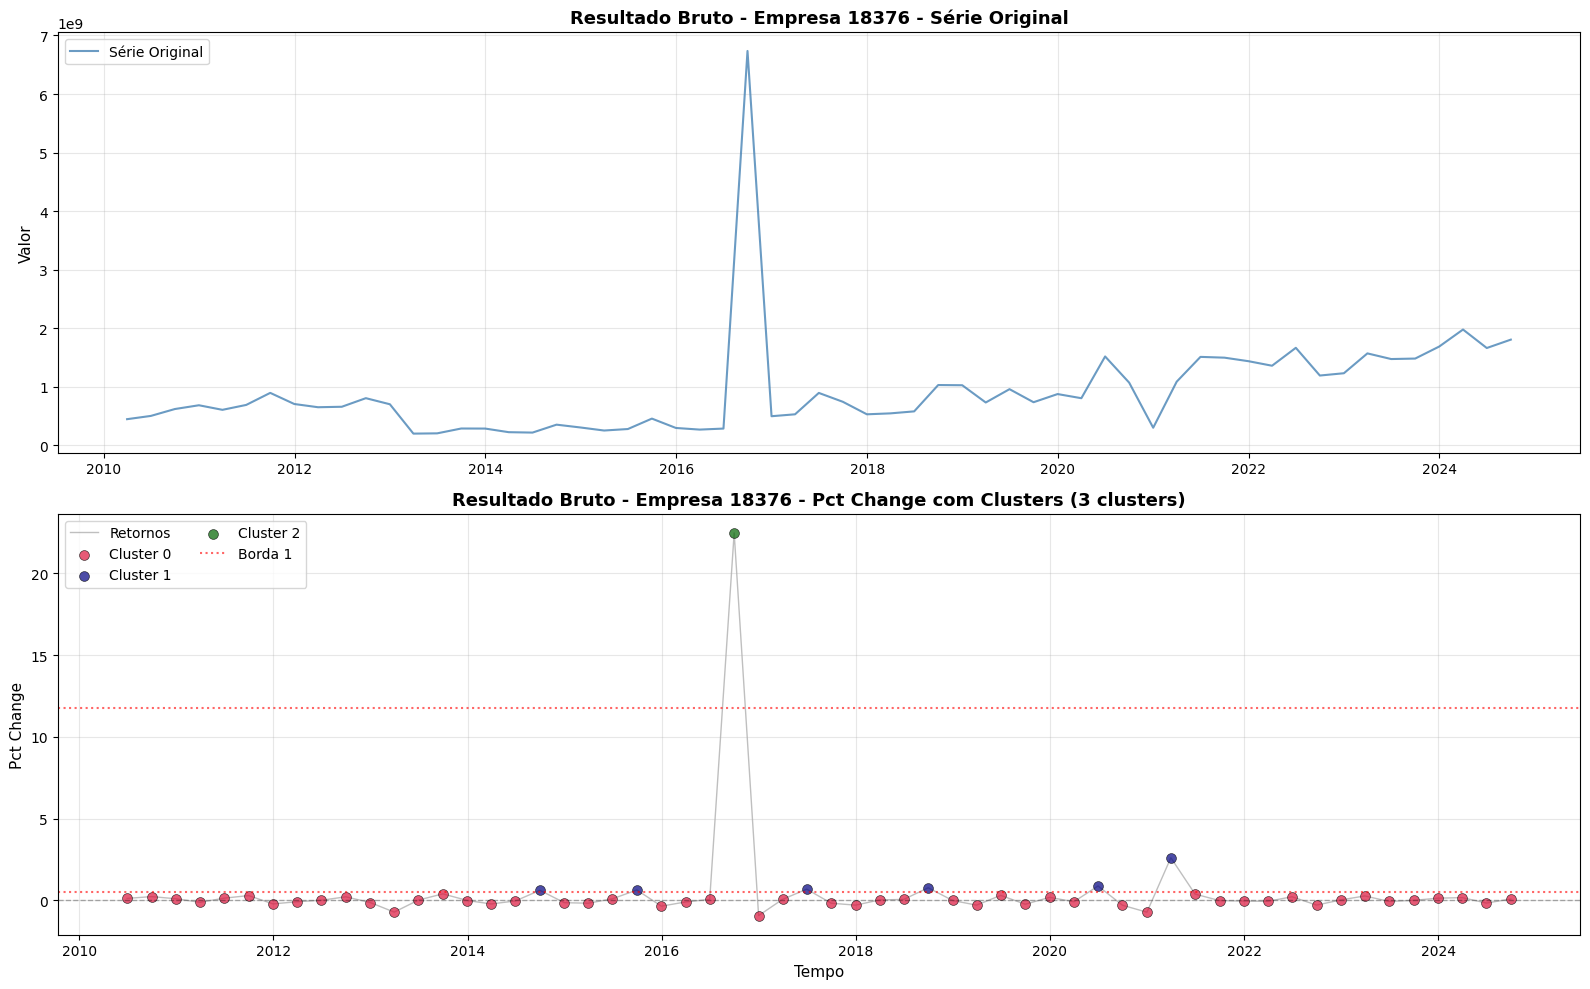


ESTATÍSTICAS DOS CLUSTERS - Resultado Bruto - Empresa 18376

Número de clusters: 3

Bordas dos Bins (K-Means):
  Borda 0: -0.926082
  Borda 1: 0.497054
  Borda 2: 11.752313
  Borda 3: 22.468416

Distribuição dos Log-Returns por Cluster:

  Cluster 0:
    N° observações: 51 (87.9%)
    Média: -0.042103
    Mediana: -0.003736
    Desvio Padrão: 0.262545
    Min/Max: -0.926082 / 0.402761

  Cluster 1:
    N° observações: 6 (10.3%)
    Média: 1.036211
    Mediana: 0.731523
    Desvio Padrão: 0.777814
    Min/Max: 0.619877 / 2.611327

  Cluster 2:
    N° observações: 1 (1.7%)
    Média: 22.468416
    Mediana: 22.468416
    Desvio Padrão: nan
    Min/Max: 22.468416 / 22.468416

--- 4 Clusters ---


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


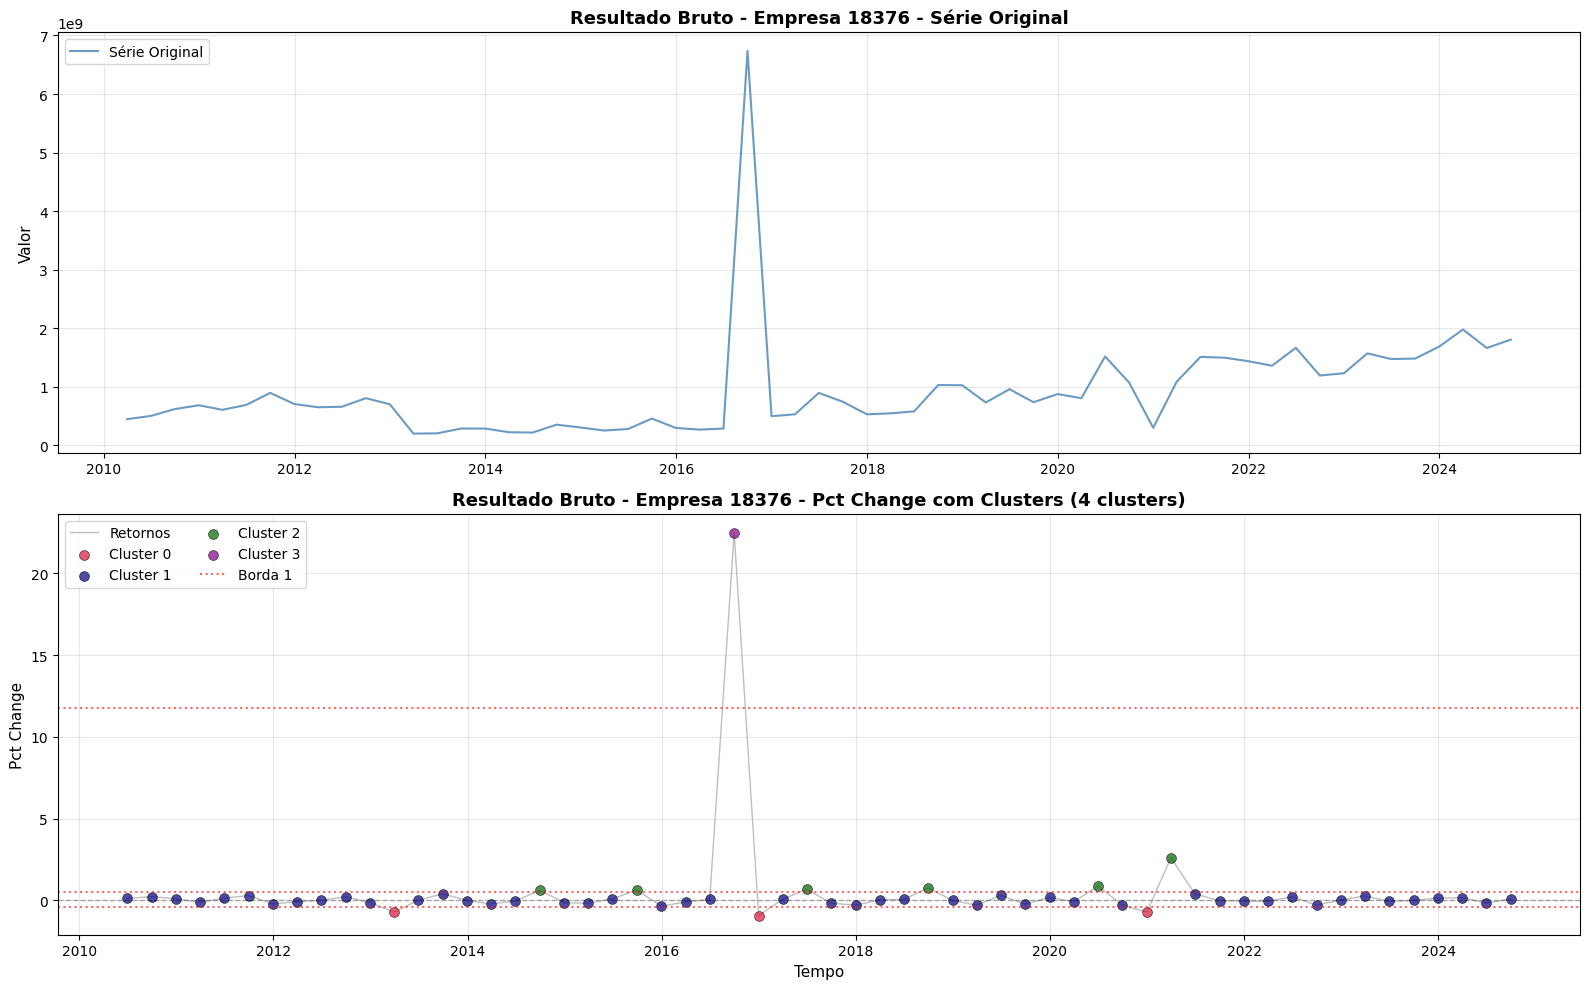


ESTATÍSTICAS DOS CLUSTERS - Resultado Bruto - Empresa 18376

Número de clusters: 4

Bordas dos Bins (K-Means):
  Borda 0: -0.926082
  Borda 1: -0.390945
  Borda 2: 0.520310
  Borda 3: 11.752313
  Borda 4: 22.468416

Distribuição dos Log-Returns por Cluster:

  Cluster 0:
    N° observações: 3 (5.2%)
    Média: -0.786300
    Mediana: -0.718845
    Desvio Padrão: 0.121080
    Min/Max: -0.926082 / -0.713972

  Cluster 1:
    N° observações: 48 (82.8%)
    Média: 0.004409
    Mediana: 0.001171
    Desvio Padrão: 0.187472
    Min/Max: -0.349783 / 0.402761

  Cluster 2:
    N° observações: 6 (10.3%)
    Média: 1.036211
    Mediana: 0.731523
    Desvio Padrão: 0.777814
    Min/Max: 0.619877 / 2.611327

  Cluster 3:
    N° observações: 1 (1.7%)
    Média: 22.468416
    Mediana: 22.468416
    Desvio Padrão: nan
    Min/Max: 22.468416 / 22.468416

COMPARAÇÃO DE CLUSTERS - MÚLTIPLOS INDICADORES


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


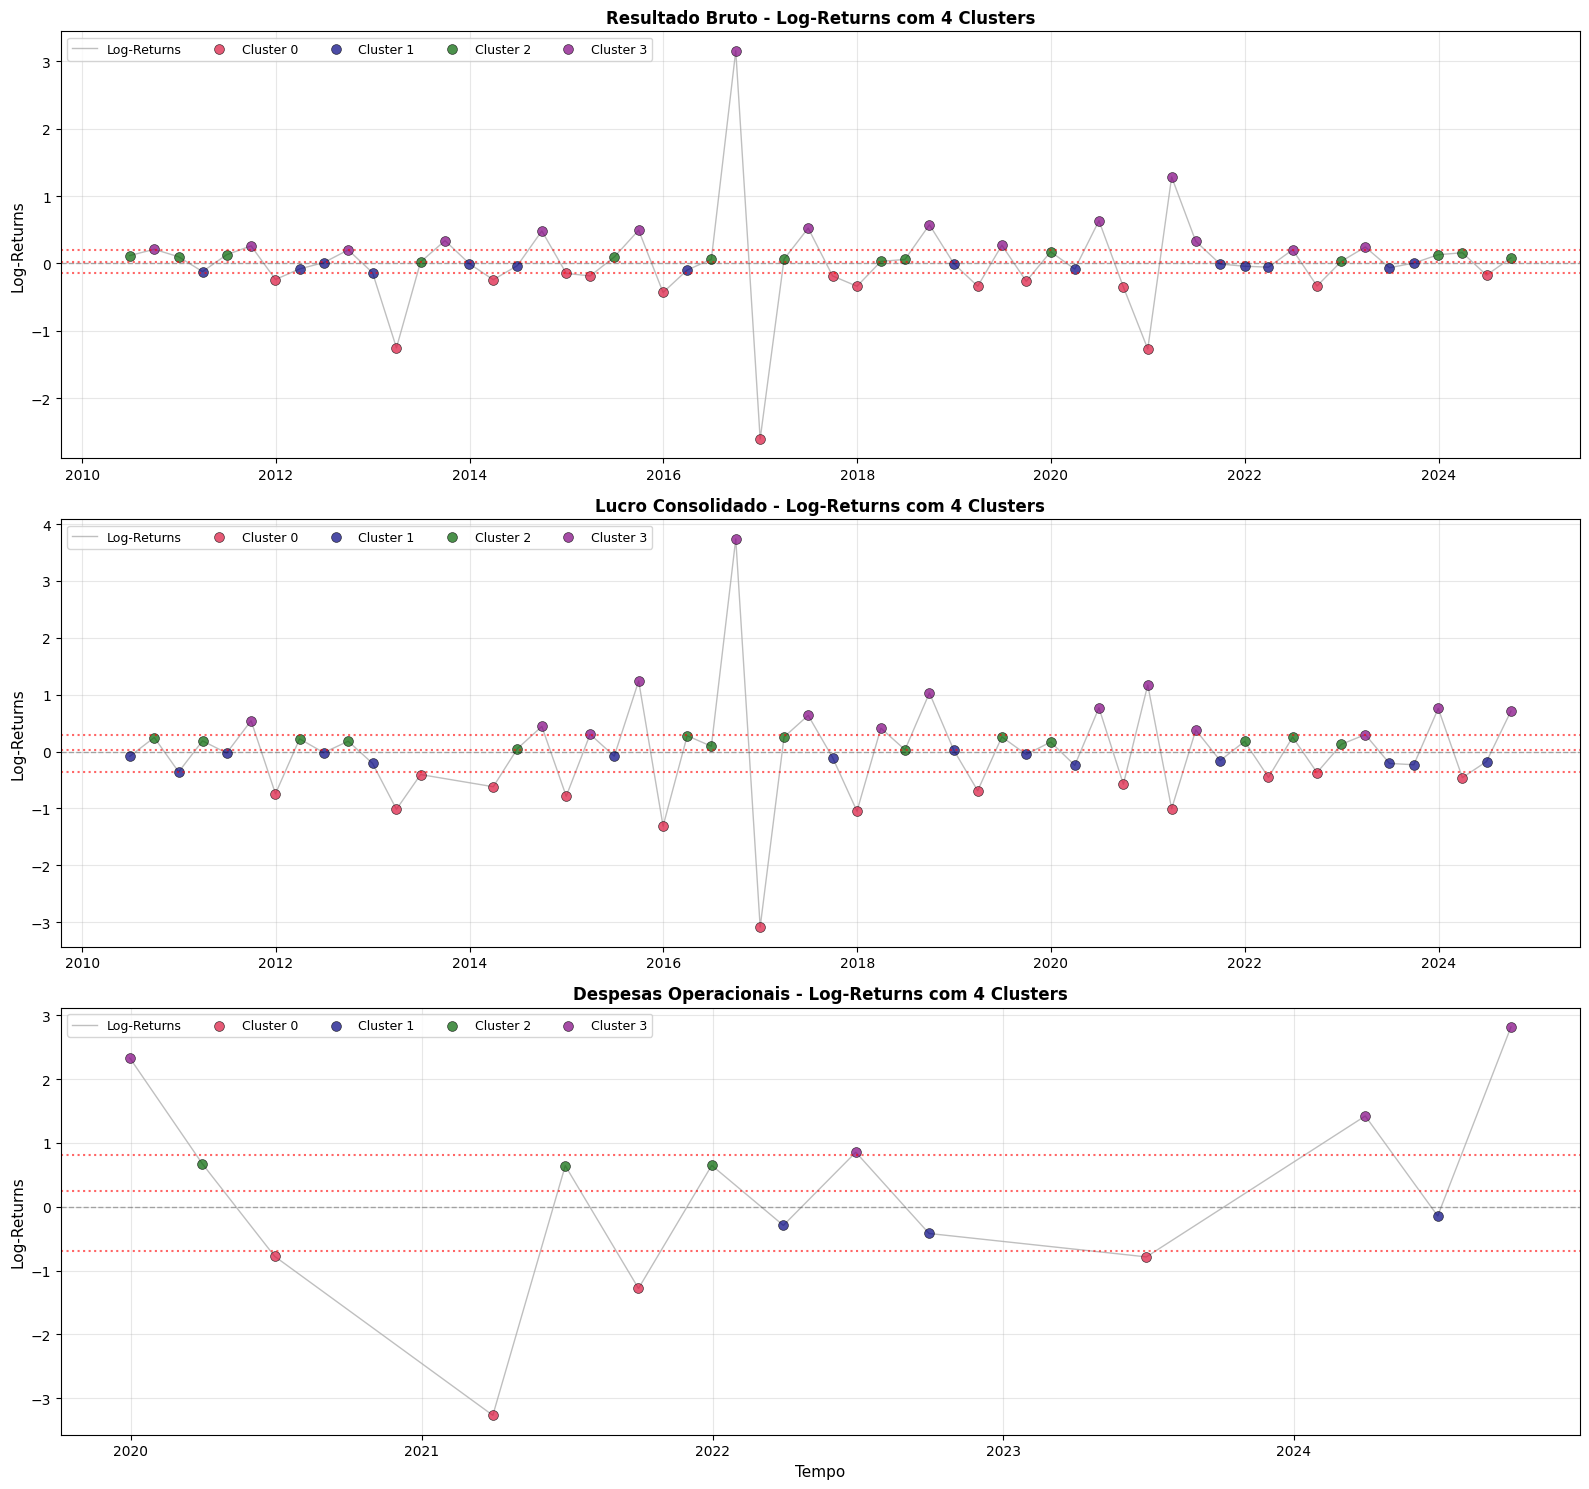

In [8]:
#Analise de clusters para uma empresa
print("="*70)
print("ANÁLISE DE CLUSTERS - EMPRESA INDIVIDUAL")
print("="*70)

empresa_teste = '18376'
resultado_clusters = plotar_log_returns_clusters(
    serie=resultado_bruto[empresa_teste],
    bins=4,
    nome_serie=f'Resultado Bruto - Empresa {empresa_teste}',
    tipo_clusterizacao='quantile',
    usar_log_returns=True
)

# Histograma
plotar_histograma_clusters(
    serie=resultado_bruto[empresa_teste],
    bins=4,
    nome_serie=f'Resultado Bruto - Empresa {empresa_teste}', tipo_clusterizacao='quantile',
    usar_log_returns=True
)

# Exemplo 2: Comparação entre empresas
print("\n" + "="*70)
print("COMPARAÇÃO DE CLUSTERS - MÚLTIPLAS EMPRESAS")
print("="*70)

empresas_comparar = ['21490', '2437', '20257', '18376']
series_dict = {
    f'Empresa {emp}': resultado_bruto[emp] 
    for emp in empresas_comparar
}

plotar_comparacao_clusters_multiplas_series(series_dict, bins=4, usar_log_returns=True, tipo_clusterizacao='quantile')

# Exemplo 3: Diferentes números de clusters
print("\n" + "="*70)
print("TESTE COM DIFERENTES NÚMEROS DE CLUSTERS")
print("="*70)

empresa_analise = '18376'
for n_clusters in [3, 4]:
    print(f"\n--- {n_clusters} Clusters ---")
    plotar_log_returns_clusters(
        serie=resultado_bruto[empresa_analise],
        bins=n_clusters,
        nome_serie=f'Resultado Bruto - Empresa {empresa_analise}'
    )

# Exemplo 4: Comparação entre indicadores da mesma empresa
print("\n" + "="*70)
print("COMPARAÇÃO DE CLUSTERS - MÚLTIPLOS INDICADORES")
print("="*70)

empresa_analise = '18376'
indicadores_dict = {
    'Resultado Bruto': resultado_bruto[empresa_analise],
    'Lucro Consolidado': lucro_consolidado[empresa_analise],
    'Despesas Operacionais': despesas_operacionais[empresa_analise]
}

plotar_comparacao_clusters_multiplas_series(indicadores_dict, bins=4, usar_log_returns=True, tipo_clusterizacao='quantile')

### Grid Search

In [ ]:
def hmm_grid_search_discretizado(serie_receita, estados_range=(2, 6), bins_range=(2, 11), janela=12, n_iter=100, random_series=[1,42,6,99,7,150,33,25,21,12,200,2,3,4,5,6,100,350,2,3,4,5], plot_pred_real=True):
    """
    Grid search para HMM variando número de estados e bins de discretização.

    Args:
        serie_receita: série temporal de receita (já discretizada, shape (n,1))
        estados_range: tuple (min, max) para número de estados
        bins_range: tuple (min, max) para número de bins
        janela: tamanho da janela rolling
        n_iter: iterações do algoritmo Baum-Welch
        random_series: lista de seeds para testar

    Returns:
        DataFrame com resultados ordenados por acurácia
    """
    resultados = []

    def _metricas_confusao(cm: np.ndarray):
        total = cm.sum()
        acc_global = np.trace(cm) / total if total > 0 else np.nan

        suporte = cm.sum(axis=1)
        pred_sum = cm.sum(axis=0)

        recall_por_cls = np.divide(np.diag(cm), suporte, out=np.zeros_like(suporte, dtype=float), where=suporte != 0)
        precision_por_cls = np.divide(np.diag(cm), pred_sum, out=np.zeros_like(pred_sum, dtype=float), where=pred_sum != 0)
        f1_por_cls = np.divide(2 * precision_por_cls * recall_por_cls,
                               precision_por_cls + recall_por_cls,
                               out=np.zeros_like(precision_por_cls, dtype=float),
                               where=(precision_por_cls + recall_por_cls) != 0)

        macro_prec = np.nanmean(precision_por_cls)
        macro_rec = np.nanmean(recall_por_cls)
        macro_f1 = np.nanmean(f1_por_cls)

        weights = suporte / total if total > 0 else np.zeros_like(suporte, dtype=float)
        weighted_prec = np.nansum(weights * precision_por_cls)
        weighted_rec = np.nansum(weights * recall_por_cls)
        weighted_f1 = np.nansum(weights * f1_por_cls)

        return {
            'acc_global': acc_global,
            'precision_macro': macro_prec,
            'recall_macro': macro_rec,
            'f1_macro': macro_f1,
            'precision_weighted': weighted_prec,
            'recall_weighted': weighted_rec,
            'f1_weighted': weighted_f1,
            'precision_por_cluster': precision_por_cls,
            'recall_por_cluster': recall_por_cls,
            'f1_por_cluster': f1_por_cls
        }

    # Gera todas as combinações
    combinacoes = list(product(
        range(estados_range[0], estados_range[1]),
        range(bins_range[0], bins_range[1])
    ))

    print(f"Testando {len(combinacoes)} combinações...")

    for n_estados, n_bins in combinacoes:
        try:
            obs = serie_receita.copy()

            for r in random_series:
                preds, reals = [], []

                for i in range(janela, len(obs)):
                    history = obs[i - janela:i]

                    model = hmm.CategoricalHMM(
                        n_components=n_estados,
                        n_iter=n_iter,
                        random_state=r,
                        verbose=False
                    )
                    model.fit(history)

                    estado_atual = model.predict(history)[-1]
                    probs_prox_obs = model.transmat_[estado_atual] @ model.emissionprob_
                    prox_simbolo = int(np.argmax(probs_prox_obs))

                    preds.append(prox_simbolo)
                    reals.append(int(obs[i][0]))

                if not preds:
                    continue
                
                labels_cm = sorted(set(reals) | set(preds))
                cm = confusion_matrix(reals, preds, labels=labels_cm)
                acc = accuracy_score(reals, preds)
                met = _metricas_confusao(cm)

                # Log-likelihood e critérios de informação
                log_lk = model.score(obs)
                aic, bic = _aic_bic_categorical(log_lk, n_estados, n_bins, len(obs))

                resultados.append({
                    'n_estados': n_estados,
                    'n_bins': n_bins,
                    'random_state': r,
                    'acuracia': acc,
                    'n_previsoes': len(preds),
                    'acc_global': met['acc_global'],
                    'precision_macro': met['precision_macro'],
                    'recall_macro': met['recall_macro'],
                    'f1_macro': met['f1_macro'],
                    'precision_weighted': met['precision_weighted'],
                    'recall_weighted': met['recall_weighted'],
                    'f1_weighted': met['f1_weighted'],
                    'precision_por_cluster': met['precision_por_cluster'],
                    'recall_por_cluster': met['recall_por_cluster'],
                    'f1_por_cluster': met['f1_por_cluster'],
                    'matriz_confusao': cm.tolist(),
                    'log_likelihood': log_lk,
                    'aic': aic,
                    'bic': bic
                })

                # if plot_pred_real:
                #     plt.figure(figsize=(8, 4))
                #     plt.plot(reals, label='Real', color='steelblue', linewidth=1.5)
                #     plt.plot(preds, label='Predito', color='crimson', linestyle='--', linewidth=1.2)
                #     plt.title(f'Real vs Predito | Estados={n_estados}, Bins={n_bins}, Seed={r}\nAcurácia={acc:.4f}')
                #     plt.xlabel('Passo da previsão')
                #     plt.ylabel('Classe')
                #     plt.legend()
                #     plt.grid(True, alpha=0.3)
                #     plt.tight_layout()
                #     plt.show()



                print(f"Estados={n_estados}, Bins={n_bins}, Seed={r} → Acurácia={acc:.4f} ({len(preds)} previsões) | AIC={aic:.2f}, BIC={bic:.2f}" )
        except Exception as e:
            print(f"Erro com Estados={n_estados}, Bins={n_bins}: {str(e)}")
            continue

    df_resultados = pd.DataFrame(resultados).sort_values('acuracia', ascending=False)
    return df_resultados

#################################################################################

def plotar_evolucao_aic_bic(resultado_grid):
    """Plota AIC e BIC (mínimo e média) por número de estados."""
    df = resultado_grid
    stats = df.groupby('n_estados').agg({
        'aic': ['mean', 'min'],
        'bic': ['mean', 'min']
    })

    fig, ax = plt.subplots(figsize=(10, 6))
    estados = stats.index

    ax.plot(estados, stats['aic']['mean'], 'o-', color='steelblue', label='AIC (mean)')
    ax.plot(estados, stats['aic']['min'], 'o--', color='steelblue', alpha=0.6, label='AIC (min)')
    ax.plot(estados, stats['bic']['mean'], 's-', color='darkgreen', label='BIC (mean)')
    ax.plot(estados, stats['bic']['min'], 's--', color='darkgreen', alpha=0.6, label='BIC (min)')

    ax.set_xlabel('Number of states')
    ax.set_ylabel('Criterion')
    ax.set_title('AIC and BIC evolution by number of states')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

##################################################################################
def _aic_bic_categorical(log_likelihood, n_states, n_bins, n_samples):
        # startprob: n_states-1; transmat: n_states*(n_states-1); emissões: n_states*(n_bins-1)
        n_params = (n_states - 1) + n_states * (n_states - 1) + n_states * (n_bins - 1)
        aic = -2 * log_likelihood + 2 * n_params
        bic = -2 * log_likelihood + n_params * np.log(n_samples)
        return aic, bic

In [9]:
def plotar_aic_empresas(resultados_grid_empresas, modo='min'):
    """
    Plota curvas de AIC (mínimo ou médio) por número de estados para múltiplas empresas.

    Args:
        resultados_grid_empresas: dict {empresa: df_resultados} contendo coluna 'aic'
        modo: 'min' ou 'mean' para agregar o AIC por n_estados
    """
    if modo not in ('min', 'mean'):
        raise ValueError("modo deve ser 'min' ou 'mean'")

    plt.figure(figsize=(10, 6))
    cores = ['crimson', 'navy', 'darkgreen', 'purple', 'orange', 'brown', 'gray']

    for idx, (empresa, df) in enumerate(resultados_grid_empresas.items()):
        if 'aic' not in df.columns or 'n_estados' not in df.columns:
            print(f"Empresa {empresa}: DataFrame sem colunas 'aic' ou 'n_estados'. Ignorando.")
            continue

        agg = df.groupby('n_estados')['aic'].agg(modo)
        plt.plot(agg.index, agg.values, marker='o',
                 color=cores[idx % len(cores)],
                 label=f'Empresa {empresa} (AIC {modo})')

    plt.xlabel('Número de estados')
    plt.ylabel(f'AIC ({modo})')
    plt.title('Curvas de AIC por número de estados – Múltiplas empresas')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Faz os gráficos de acurácia e AIC (com grid search)

In [14]:
for bins in range(2, 6):
    print(f"\n--- Testando bins = {bins} ---")
    obs_discretizada = discretiza_kmeans(
        resultado_bruto[empresa_teste],
        bins=bins,
        tipo_clusterizacao='quantile',
        tipo_discretizacao='log_returns'
    )
    resultados_grid = hmm_grid_search_discretizado(
        obs_discretizada,
        estados_range=(3, 4),
        bins_range=(2, 6),
        janela=25
    )
    melhor = resultados_grid.iloc[0]
    print(f"Melhor: estados={melhor['n_estados']}, bins={melhor['n_bins']}, acc={melhor['acuracia']:.4f}")


--- Testando bins = 2 ---
Bordas dos Bins (K-Means):
[-2.6048004   0.01727236  3.1556555 ]
Testando 4 combinações...
Estados=3, Bins=2, Seed=1 → Acurácia=0.5455 (33 previsões) | AIC=98.10, BIC=120.76
Estados=3, Bins=2, Seed=42 → Acurácia=0.3333 (33 previsões) | AIC=106.27, BIC=128.93
Estados=3, Bins=2, Seed=6 → Acurácia=0.6061 (33 previsões) | AIC=113.59, BIC=136.26
Estados=3, Bins=2, Seed=99 → Acurácia=0.2727 (33 previsões) | AIC=104.88, BIC=127.54
Estados=3, Bins=2, Seed=7 → Acurácia=0.3636 (33 previsões) | AIC=96.44, BIC=119.10
Estados=3, Bins=2, Seed=150 → Acurácia=0.3636 (33 previsões) | AIC=100.07, BIC=122.74
Estados=3, Bins=2, Seed=33 → Acurácia=0.5152 (33 previsões) | AIC=100.17, BIC=122.83
Estados=3, Bins=2, Seed=25 → Acurácia=0.4242 (33 previsões) | AIC=102.39, BIC=125.05
Estados=3, Bins=2, Seed=21 → Acurácia=0.2727 (33 previsões) | AIC=102.49, BIC=125.15
Estados=3, Bins=2, Seed=12 → Acurácia=0.5455 (33 previsões) | AIC=100.81, BIC=123.47
Estados=3, Bins=2, Seed=200 → Acurác

18376 Bordas dos Bins (K-Means):
[-2.6048004  -0.08123025  0.11729566  3.1556555 ]
Testando 12 combinações...
Estados=2, Bins=2, Seed=1 → Acurácia=0.2609 (23 previsões) | AIC=133.64, BIC=143.95
Estados=2, Bins=2, Seed=42 → Acurácia=0.3043 (23 previsões) | AIC=146.63, BIC=156.93
Estados=2, Bins=2, Seed=6 → Acurácia=0.2609 (23 previsões) | AIC=133.73, BIC=144.03
Estados=2, Bins=2, Seed=99 → Acurácia=0.2609 (23 previsões) | AIC=143.53, BIC=153.83
Estados=2, Bins=2, Seed=7 → Acurácia=0.3043 (23 previsões) | AIC=133.24, BIC=143.54
Estados=2, Bins=2, Seed=150 → Acurácia=0.2174 (23 previsões) | AIC=138.08, BIC=148.38
Estados=2, Bins=2, Seed=33 → Acurácia=0.3043 (23 previsões) | AIC=158.18, BIC=168.48
Estados=2, Bins=2, Seed=25 → Acurácia=0.2609 (23 previsões) | AIC=133.04, BIC=143.34
Estados=2, Bins=2, Seed=21 → Acurácia=0.3478 (23 previsões) | AIC=133.06, BIC=143.36
Estados=2, Bins=2, Seed=12 → Acurácia=0.2174 (23 previsões) | AIC=137.92, BIC=148.22
Estados=2, Bins=2, Seed=200 → Acurácia=0.3

,n_estados,n_bins,random_state,acuracia,n_previsoes,acc_global,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_por_cluster,recall_por_cluster,f1_por_cluster,matriz_confusao,log_likelihood,aic,bic
149,3,4,350,0.478261,23,0.478261,0.525000,0.481481,0.480672,0.548913,0.478261,0.488564,"[0.375, 0.4, 0.8]","[0.42857142857142855, 0.5714285714285714, 0.44...","[0.39999999999999997, 0.47058823529411764, 0.5...","[[3, 4, 0], [2, 4, 1], [3, 2, 4]]",-53.805311,141.610621,176.638152
176,4,2,1,0.478261,23,0.478261,0.500000,0.492063,0.477498,0.508696,0.478261,0.473243,"[0.5, 0.4, 0.6]","[0.5714285714285714, 0.5714285714285714, 0.333...","[0.5333333333333333, 0.47058823529411764, 0.42...","[[4, 2, 1], [2, 4, 1], [2, 4, 3]]",-92.267759,222.535518,261.683935
242,4,5,1,0.478261,23,0.478261,0.500000,0.492063,0.477498,0.508696,0.478261,0.473243,"[0.5, 0.4, 0.6]","[0.5714285714285714, 0.5714285714285714, 0.333...","[0.5333333333333333, 0.47058823529411764, 0.42...","[[4, 2, 1], [2, 4, 1], [2, 4, 3]]",-92.267759,246.535518,310.409251
171,3,5,350,0.478261,23,0.478261,0.525000,0.481481,0.480672,0.548913,0.478261,0.488564,"[0.375, 0.4, 0.8]","[0.42857142857142855, 0.5714285714285714, 0.44...","[0.39999999999999997, 0.47058823529411764, 0.5...","[[3, 4, 0], [2, 4, 1], [3, 2, 4]]",-53.805311,147.610621,188.819481
220,4,4,1,0.478261,23,0.478261,0.500000,0.492063,0.477498,0.508696,0.478261,0.473243,"[0.5, 0.4, 0.6]","[0.5714285714285714, 0.5714285714285714, 0.333...","[0.5333333333333333, 0.47058823529411764, 0.42...","[[4, 2, 1], [2, 4, 1], [2, 4, 3]]",-92.267759,238.535518,294.167479
127,3,3,350,0.478261,23,0.478261,0.525000,0.481481,0.480672,0.548913,0.478261,0.488564,"[0.375, 0.4, 0.8]","[0.42857142857142855, 0.5714285714285714, 0.44...","[0.39999999999999997, 0.47058823529411764, 0.5...","[[3, 4, 0], [2, 4, 1], [3, 2, 4]]",-53.805311,135.610621,164.456823
105,3,2,350,0.478261,23,0.478261,0.525000,0.481481,0.480672,0.548913,0.478261,0.488564,"[0.375, 0.4, 0.8]","[0.42857142857142855, 0.5714285714285714, 0.44...","[0.39999999999999997, 0.47058823529411764, 0.5...","[[3, 4, 0], [2, 4, 1], [3, 2, 4]]",-53.805311,129.610621,152.275494
198,4,3,1,0.478261,23,0.478261,0.500000,0.492063,0.477498,0.508696,0.478261,0.473243,"[0.5, 0.4, 0.6]","[0.5714285714285714, 0.5714285714285714, 0.333...","[0.5333333333333333, 0.47058823529411764, 0.42...","[[4, 2, 1], [2, 4, 1], [2, 4, 3]]",-92.267759,230.535518,277.925707
235,4,4,6,0.434783,23,0.434783,0.434524,0.444444,0.438282,0.429348,0.434783,0.430861,"[0.5, 0.42857142857142855, 0.375]","[0.5714285714285714, 0.42857142857142855, 0.33...","[0.5333333333333333, 0.42857142857142855, 0.35...","[[4, 1, 2], [1, 3, 3], [3, 3, 3]]",-60.362857,174.725715,230.357676
130,3,3,4,0.434783,23,0.434783,0.439815,0.444444,0.433333,0.445048,0.434783,0.430435,"[0.375, 0.4444444444444444, 0.5]","[0.42857142857142855, 0.5714285714285714, 0.33...","[0.39999999999999997, 0.5, 0.4]","[[3, 2, 2], [2, 4, 1], [3, 3, 3]]",-63.520844,155.041688,183.887890



=== Melhor Configuração ===
Estados: 3, Bins: 4, Acurácia: 0.4783


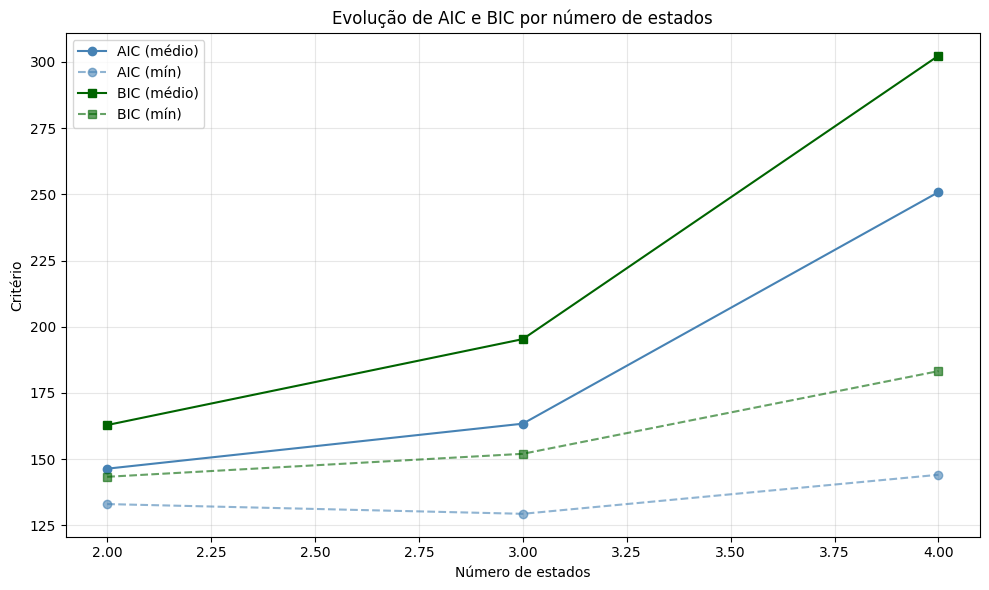

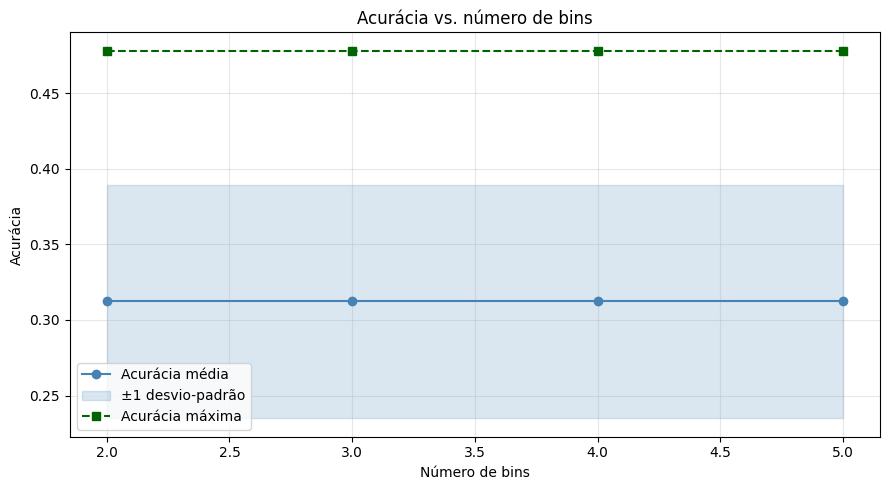

In [17]:
# Teste para uma empresa
empresa_teste = '18376'
#resultados_grid_empresa = {}
#for empresa in resultado_bruto.columns:
print(f"{empresa_teste} ", end='')
resultados_grid = hmm_grid_search_discretizado(
    discretiza_kmeans(resultado_bruto[empresa_teste], bins=3,tipo_clusterizacao='quantile', tipo_discretizacao='log_returns'),
    estados_range=(2,5),
    bins_range=(2,6),
    janela=35
)

print("\n=== Top 10 Melhores Configurações ===")
display(resultados_grid.head(10))

print("\n=== Melhor Configuração ===")
melhor = resultados_grid.iloc[0]
print(f"Estados: {melhor['n_estados']}, Bins: {melhor['n_bins']}, Acurácia: {melhor['acuracia']:.4f}")


#plotar_aic_empresas(resultados_grid_empresa, modo='min')
plotar_evolucao_aic_bic(resultados_grid)
plotar_acuracia_por_bins(resultados_grid, agg_mean=True)

In [18]:
def plotar_acuracia_por_bins(resultado_grid, agg_mean=True):
    """
    Plota acurácia média (e min/max) conforme o número de bins varia.

    Args:
        resultado_grid: DataFrame com colunas 'n_bins' e 'acuracia'
        agg_mean: se True, plota média com faixa de desvio-padrão e marcador do máx.
    """
    df = resultado_grid
    if not {'n_bins', 'acuracia'}.issubset(df.columns):
        raise ValueError("resultado_grid precisa ter colunas 'n_bins' e 'acuracia'")

    stats = df.groupby('n_bins')['acuracia'].agg(['mean', 'std', 'min', 'max'])
    bins = stats.index

    plt.figure(figsize=(9, 5))
    if agg_mean:
        plt.plot(bins, stats['mean'], 'o-', color='steelblue', label='Acurácia média')
        plt.fill_between(bins,
                         stats['mean'] - stats['std'],
                         stats['mean'] + stats['std'],
                         color='steelblue', alpha=0.2, label='±1 desvio-padrão')
        plt.plot(bins, stats['max'], 's--', color='darkgreen', label='Acurácia máxima')
    else:
        plt.plot(bins, stats['min'], 'o--', color='crimson', label='Acurácia mínima')
        plt.plot(bins, stats['max'], 's-', color='darkgreen', label='Acurácia máxima')

    plt.xlabel('Número de bins')
    plt.ylabel('Acurácia')
    plt.title('Acurácia vs. número de bins')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [58]:
# Teste para uma empresa
empresa_teste = '20257'
resultados_grid = hmm_grid_search_discretizado(
    discretiza_kmeans(resultado_bruto['2437'], bins=3),
    estados_range=(2,5),
    bins_range=(3,4),
    janela=18
)

print("\n=== Top 10 Melhores Configurações ===")
display(resultados_grid.head(10))

print("\n=== Melhor Configuração ===")
melhor = resultados_grid.iloc[0]
print(f"Estados: {melhor['n_estados']}, Bins: {melhor['n_bins']}, Acurácia: {melhor['acuracia']:.4f}")

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Bordas dos Bins (K-Means):
[-1.34640617 -0.03940996  0.08500885  1.58786381]
Testando 3 combinações...
Estados=2, Bins=3, Seed=1 → Acurácia=0.3158 (38 previsões) | AIC=138.29, BIC=152.47
Estados=2, Bins=3, Seed=42 → Acurácia=0.1579 (38 previsões) | AIC=147.76, BIC=161.94
Estados=2, Bins=3, Seed=6 → Acurácia=0.3421 (38 previsões) | AIC=513.71, BIC=527.89
Estados=2, Bins=3, Seed=42 → Acurácia=0.1579 (38 previsões) | AIC=147.76, BIC=161.94
Estados=2, Bins=3, Seed=6 → Acurácia=0.3421 (38 previsões) | AIC=513.71, BIC=527.89
Estados=2, Bins=3, Seed=99 → Acurácia=0.2895 (38 previsões) | AIC=139.00, BIC=153.18
Estados=2, Bins=3, Seed=7 → Acurácia=0.4737 (38 previsões) | AIC=450.21, BIC=464.38
Estados=2, Bins=3, Seed=99 → Acurácia=0.2895 (38 previsões) | AIC=139.00, BIC=153.18
Estados=2, Bins=3, Seed=7 → Acurácia=0.4737 (38 previsões) | AIC=450.21, BIC=464.38
Estados=2, Bins=3, Seed=150 → Acurácia=0.1842 (38 previsões) | AIC=559.02, BIC=573.20
Estados=2, Bins=3, Seed=33 → Acurácia=0.2105 (38 pr

Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a 

Estados=3, Bins=3, Seed=5 → Acurácia=0.2632 (38 previsões) | AIC=179.71, BIC=208.07


Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a 

...

Estados=4, Bins=3, Seed=3 → Acurácia=0.4474 (38 previsões) | AIC=1100.12, BIC=1146.71


Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a model with 23 free scalar parameters with only 18 data points will result in a degenerate solution.
Fitting a 

Estados=4, Bins=3, Seed=4 → Acurácia=0.2105 (38 previsões) | AIC=237.59, BIC=284.17
Estados=4, Bins=3, Seed=5 → Acurácia=0.3684 (38 previsões) | AIC=247.95, BIC=294.53

=== Top 10 Melhores Configurações ===


,n_estados,n_bins,random_state,acuracia,n_previsoes,acc_global,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_por_cluster,recall_por_cluster,f1_por_cluster,matriz_confusao,log_likelihood,aic,bic
22,3,3,1,0.500000,38,0.500000,0.480927,0.500000,0.484895,0.483704,0.500000,0.485811,"[0.5882352941176471, 0.45454545454545453, 0.4]","[0.7142857142857143, 0.5, 0.2857142857142857]","[0.6451612903225806, 0.47619047619047616, 0.33...","[[10, 1, 3], [2, 5, 3], [5, 5, 4]]",-238.781099,505.562197,533.917121
23,3,3,42,0.500000,38,0.500000,0.463624,0.490476,0.459831,0.465643,0.500000,0.463913,"[0.5714285714285714, 0.4444444444444444, 0.375]","[0.8571428571428571, 0.4, 0.21428571428571427]","[0.6857142857142857, 0.4210526315789474, 0.272...","[[12, 0, 2], [3, 4, 3], [6, 5, 3]]",-161.145913,350.291826,378.646750
4,2,3,7,0.473684,38,0.473684,0.452381,0.457143,0.452381,0.460526,0.473684,0.464912,"[0.625, 0.375, 0.35714285714285715]","[0.7142857142857143, 0.3, 0.35714285714285715]","[0.6666666666666666, 0.33333333333333326, 0.35...","[[10, 0, 4], [2, 3, 5], [4, 5, 5]]",-218.103241,450.206482,464.383944
9,2,3,12,0.473684,38,0.473684,0.417934,0.466667,0.433729,0.419821,0.473684,0.437279,"[0.631578947368421, 0.4, 0.2222222222222222]","[0.8571428571428571, 0.4, 0.14285714285714285]","[0.7272727272727273, 0.4000000000000001, 0.173...","[[12, 0, 2], [1, 4, 5], [6, 6, 2]]",-256.367119,526.734237,540.911699
47,4,3,99,0.447368,38,0.447368,0.399784,0.442857,0.406162,0.403589,0.447368,0.408816,"[0.55, 0.36363636363636365, 0.2857142857142857]","[0.7857142857142857, 0.4, 0.14285714285714285]","[0.6470588235294117, 0.380952380952381, 0.1904...","[[11, 1, 2], [3, 4, 3], [6, 6, 2]]",-2009.150022,4064.300044,4110.883133
63,4,3,3,0.447368,38,0.447368,0.452381,0.461905,0.448413,0.454887,0.447368,0.442982,"[0.5, 0.42857142857142855, 0.42857142857142855]","[0.35714285714285715, 0.6, 0.42857142857142855]","[0.41666666666666663, 0.5, 0.42857142857142855]","[[5, 4, 5], [1, 6, 3], [4, 4, 6]]",-527.062185,1100.124370,1146.707459
59,4,3,6,0.447368,38,0.447368,0.442810,0.433333,0.435288,0.454334,0.447368,0.447867,"[0.4117647058823529, 0.3333333333333333, 0.583...","[0.5, 0.3, 0.5]","[0.45161290322580644, 0.3157894736842105, 0.53...","[[7, 4, 3], [5, 3, 2], [5, 2, 7]]",-80.432933,206.865866,253.448955
52,4,3,21,0.447368,38,0.447368,0.418301,0.452381,0.415054,0.427245,0.447368,0.416638,"[0.5882352941176471, 0.3333333333333333, 0.333...","[0.7142857142857143, 0.5, 0.14285714285714285]","[0.6451612903225806, 0.4, 0.2]","[[10, 2, 2], [3, 5, 2], [4, 8, 2]]",-inf,inf,inf
46,4,3,6,0.447368,38,0.447368,0.442810,0.433333,0.435288,0.454334,0.447368,0.447867,"[0.4117647058823529, 0.3333333333333333, 0.583...","[0.5, 0.3, 0.5]","[0.45161290322580644, 0.3157894736842105, 0.53...","[[7, 4, 3], [5, 3, 2], [5, 2, 7]]",-80.432933,206.865866,253.448955
21,2,3,5,0.447368,38,0.447368,0.384600,0.433333,0.400395,0.393506,0.447368,0.410963,"[0.631578947368421, 0.3, 0.2222222222222222]","[0.8571428571428571, 0.3, 0.14285714285714285]","[0.7272727272727273, 0.3, 0.17391304347826086]","[[12, 0, 2], [2, 3, 5], [5, 7, 2]]",-312.306420,638.612840,652.790302



=== Melhor Configuração ===
Estados: 3, Bins: 3, Acurácia: 0.5000


### Variações de bins

In [20]:
for bins in range(2, 6):
    print(f"\n--- Testando bins = {bins} ---")
    obs_discretizada = discretiza_kmeans(
        resultado_bruto['18376'],
        bins=bins,
        tipo_clusterizacao='quantile',
        tipo_discretizacao='log_returns'
    )
    resultados_grid = hmm_grid_search_discretizado(
        obs_discretizada,
        estados_range=(3,4),
        bins_range=(2,3),
        janela=35
    )
    melhor = resultados_grid.iloc[0]
    print(f"Melhor: estados={melhor['n_estados']}, bins={melhor['n_bins']}, acc={melhor['acuracia']:.4f}")
# ...existing code...


--- Testando bins = 2 ---
Bordas dos Bins (K-Means):
[-2.6048004   0.01727236  3.1556555 ]
Testando 1 combinações...
Estados=3, Bins=2, Seed=1 → Acurácia=0.6522 (23 previsões) | AIC=106.76, BIC=129.42
Estados=3, Bins=2, Seed=42 → Acurácia=0.3043 (23 previsões) | AIC=102.66, BIC=125.32
Estados=3, Bins=2, Seed=6 → Acurácia=0.6087 (23 previsões) | AIC=191.62, BIC=214.28
Estados=3, Bins=2, Seed=99 → Acurácia=0.4348 (23 previsões) | AIC=127.38, BIC=150.05
Estados=3, Bins=2, Seed=7 → Acurácia=0.6087 (23 previsões) | AIC=113.00, BIC=135.67
Estados=3, Bins=2, Seed=150 → Acurácia=0.3913 (23 previsões) | AIC=102.63, BIC=125.30
Estados=3, Bins=2, Seed=33 → Acurácia=0.5652 (23 previsões) | AIC=118.44, BIC=141.10
Estados=3, Bins=2, Seed=25 → Acurácia=0.6087 (23 previsões) | AIC=111.36, BIC=134.03
Estados=3, Bins=2, Seed=21 → Acurácia=0.4348 (23 previsões) | AIC=113.58, BIC=136.25
Estados=3, Bins=2, Seed=12 → Acurácia=0.4783 (23 previsões) | AIC=106.97, BIC=129.64
Estados=3, Bins=2, Seed=200 → Acur

### Comparar empresas (acurácia)

In [ ]:
def hmm_grid_search_multiplas_empresas(empresas_list, indicador_series, nome_indicador,
                                       estados_range=(2, 6), bins_range=(2, 4),
                                       janela=12, n_iter=500,
                                       random_series=[1, 42, 6, 99, 7, 150, 33, 25, 21, 12, 200, 2, 3, 4, 5, 6, 100, 350, 8, 9, 10],
                                       tipo_discretizacao='kmeans'):
    """
    Grid search para HMM em múltiplas empresas e plota comparação dos melhores modelos.

    Args:
        empresas_list: lista de códigos das empresas
        indicador_series: DataFrame com séries do indicador por empresa
        nome_indicador: nome do indicador (ex: 'Resultado Bruto')
        estados_range: tuple (min, max) para número de estados
        bins_range: tuple (min, max) para número de bins
        janela: tamanho da janela rolling
        n_iter: iterações do algoritmo Baum-Welch
        random_series: lista de seeds para testar

    Returns:
        dict com resultados de grid search e melhores modelos por empresa
    """
    resultados_empresas = {}
    melhores_modelos = {}

    print(f"\n{'=' * 70}")
    print(f"GRID SEARCH HMM - {nome_indicador} - MÚLTIPLAS EMPRESAS")
    print(f"{'=' * 70}")
    print(f"Empresas: {empresas_list}")
    print(f"Testando estados: {list(range(estados_range[0], estados_range[1]))}")
    print(f"Testando bins: {list(range(bins_range[0], bins_range[1]))}")
    print(f"Seeds: {random_series}")
    print('=' * 70)

    for empresa in empresas_list:
        print(f"\n{'=' * 70}")
        print(f"PROCESSANDO EMPRESA {empresa}")
        print('=' * 70)

        try:
            if isinstance(indicador_series, pd.DataFrame):
                serie = indicador_series[empresa]
            else:
                serie = indicador_series[empresa]

            serie_limpa = (
                serie.sort_index()
                     .astype(float)
                     .replace([np.inf, -np.inf], np.nan)
                     .dropna()
            )
            serie_pct = serie_limpa.pct_change().dropna()

            if len(serie_pct) <= janela:
                print(f"⚠ Empresa {empresa}: série muito curta ({len(serie_pct)} observações)")
                continue

            resultados = []
            combinacoes = list(product(
                range(estados_range[0], estados_range[1]),
                range(bins_range[0], bins_range[1])
            ))

            print(f"Testando {len(combinacoes)} combinações de estados/bins...")

            for n_estados, n_bins in combinacoes:
                try:
                    obs = discretiza_kmeans(serie_limpa, n_bins, tipo_discretizacao)

                    if len(obs) <= janela:
                        continue

                    for r in random_series:
                        preds, reals = [], []

                        for i in range(janela, len(obs)):
                            history = obs[i - janela:i]

                            model = hmm.CategoricalHMM(
                                n_components=n_estados,
                                n_iter=n_iter,
                                random_state=r,
                                verbose=False
                            )
                            model.fit(history)

                            estado_atual = model.predict(history)[-1]
                            probs_prox_obs = model.transmat_[estado_atual] @ model.emissionprob_
                            prox_simbolo = int(np.argmax(probs_prox_obs))

                            preds.append(prox_simbolo)
                            reals.append(int(obs[i][0]))

                        if not preds:
                            continue

                        acuracia = accuracy_score(reals, preds)
                        matriz_conf = confusion_matrix(reals, preds, labels=list(range(n_bins)))

                        resultados.append({
                            'empresa': empresa,
                            'n_estados': n_estados,
                            'n_bins': n_bins,
                            'random_state': r,
                            'acuracia': acuracia,
                            'n_previsoes': len(preds),
                            'matriz_confusao': matriz_conf.tolist()
                        })

                        print(f"  Estados={n_estados}, Bins={n_bins}, Seed={r} → Acurácia={acuracia:.4f}")

                except Exception as e:
                    print(f"  Erro Estados={n_estados}, Bins={n_bins}: {str(e)}")
                    continue

            if not resultados:
                print(f"✗ Nenhum resultado válido para a empresa {empresa}")
                continue

            df_resultados = pd.DataFrame(resultados).sort_values('acuracia', ascending=False)
            resultados_empresas[empresa] = df_resultados

            melhor = df_resultados.iloc[0]
            print(f"\n✓ MELHOR MODELO EMPRESA {empresa}:")
            print(f"  Estados: {melhor['n_estados']}, Bins: {melhor['n_bins']}, Seed: {melhor['random_state']}")
            print(f"  Acurácia: {melhor['acuracia']:.4f} ({melhor['n_previsoes']} previsões)")

            obs_final = discretiza_kmeans(serie_limpa, int(melhor['n_bins']), tipo_discretizacao)

            model_final = hmm.CategoricalHMM(
                n_components=int(melhor['n_estados']),
                n_iter=n_iter,
                random_state=int(melhor['random_state'])
            )
            model_final.fit(obs_final)
            _, estados_final = model_final.decode(obs_final)

            melhores_modelos[empresa] = {
                'serie_original': serie_limpa.loc[serie_pct.index],
                'serie_pct': serie_pct,
                'estados': estados_final,
                'index': serie_pct.index,
                'modelo': model_final,
                'melhor_config': melhor,
                'convergiu': model_final.monitor_.converged,
                'log_likelihood': model_final.monitor_.history[-1] if model_final.monitor_.history else np.nan
            }

        except Exception as e:
            print(f"✗ ERRO EMPRESA {empresa}: {str(e)}")
            continue

    if not melhores_modelos:
        raise ValueError("Nenhum modelo foi treinado com sucesso!")

    plotar_comparacao_melhores_modelos(melhores_modelos, nome_indicador)
    resumo_comparativo(resultados_empresas, melhores_modelos, nome_indicador)

    return {
        'resultados_empresas': resultados_empresas,
        'melhores_modelos': melhores_modelos,
        'nome_indicador': nome_indicador
    }


def plotar_comparacao_melhores_modelos(melhores_modelos, nome_indicador):
    """
    Plota comparação dos melhores modelos de múltiplas empresas.

    Args:
        melhores_modelos: dict com melhores modelos por empresa
        nome_indicador: nome do indicador
    """
    n_empresas = len(melhores_modelos)
    fig, axes = plt.subplots(n_empresas + 1, 1, figsize=(15, 4 * (n_empresas + 1)))

    if n_empresas == 1:
        axes = [axes]

    cores_estados_base = ['crimson', 'navy', 'darkgreen', 'purple', 'orange', 'brown']

    for i, (empresa, dados) in enumerate(melhores_modelos.items()):
        ax = axes[i]
        ax.plot(dados['index'], dados['serie_original'].loc[dados['index']],
                color='steelblue', label=f'{nome_indicador} (valor)', alpha=0.7, linewidth=1.5)

        config = dados['melhor_config']
        ax.set_ylabel(nome_indicador, fontsize=11)
        ax.set_title(
            f'{nome_indicador} – Empresa {empresa} | '
            f'Estados={int(config["n_estados"])}, Bins={int(config["n_bins"])}, '
            f'Acurácia={config["acuracia"]:.2%}',
            fontsize=12, fontweight='bold'
        )
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')

        ax2 = ax.twinx()
        n_estados = int(config['n_estados'])

        tam_min = min(len(dados['index']), len(dados['estados']))
        idx_alinhado = dados['index'][:tam_min]
        estados_alinhados = dados['estados'][:tam_min]

        for estado in range(n_estados):
            mascara = estados_alinhados == estado
            ax2.scatter(idx_alinhado[mascara],
                        [estado] * mascara.sum(),
                        c=cores_estados_base[estado % len(cores_estados_base)],
                        s=50, alpha=0.6, label=f'Estado {estado}', marker='s')

        ax2.step(idx_alinhado, estados_alinhados, where='mid',
                 color='crimson', linewidth=1.5, alpha=0.3)
        ax2.set_ylabel('HMM States', fontsize=11)
        ax2.set_yticks(range(n_estados))
        ax2.set_yticklabels([f'S{i}' for i in range(n_estados)])
        ax2.legend(loc='upper right', fontsize=9)

    ax_comp = axes[-1]
    cores_empresas = ['crimson', 'navy', 'darkgreen', 'purple', 'orange', 'brown', 'pink', 'gray']

    for idx, (empresa, dados) in enumerate(melhores_modelos.items()):
        n_estados = int(dados['melhor_config']['n_estados'])

        tam_min = min(len(dados['index']), len(dados['estados']))
        idx_alinhado = dados['index'][:tam_min]
        estados_alinhados = dados['estados'][:tam_min]
        estados_norm = estados_alinhados / (n_estados - 1) if n_estados > 1 else estados_alinhados

        ax_comp.step(idx_alinhado, estados_norm, where='mid',
                    label=f'Empresa {empresa} ({int(dados["melhor_config"]["n_estados"])} estados)',
                    linewidth=2, color=cores_empresas[idx % len(cores_empresas)],
                    alpha=0.8, linestyle='--')
        
    ax_comp.set_title(
        f'Normalized State Comparison: {nome_indicador} – Multiple Companies',
        fontsize=13, fontweight='bold'
    )
    ax_comp.set_xlabel('Time', fontsize=11)
    ax_comp.set_ylabel('Normalized State (0=Low, 1=High)', fontsize=11)
    ax_comp.set_ylim(-0.1, 1.1)
    ax_comp.legend(loc='upper left', fontsize=10, ncol=2)
    ax_comp.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def resumo_comparativo(resultados_empresas, melhores_modelos, nome_indicador):
    """
    Exibe resumo comparativo dos modelos.

    Args:
        resultados_empresas: dict com DataFrames de resultados por empresa
        melhores_modelos: dict com melhores modelos por empresa
        nome_indicador: nome do indicador
    """
    print(f"\n{'=' * 70}")
    print(f"RESUMO COMPARATIVO - {nome_indicador}")
    print('=' * 70)

    dados_resumo = []
    for empresa, dados in melhores_modelos.items():
        config = dados['melhor_config']
        dados_resumo.append({
            'Empresa': empresa,
            'Estados': int(config['n_estados']),
            'Bins': int(config['n_bins']),
            'Seed': int(config['random_state']),
            'Acurácia': config['acuracia'],
            'N_Previsões': config['n_previsoes'],
            'Convergiu': '✓' if dados['convergiu'] else '✗',
            'Log-Likelihood': dados['log_likelihood']
        })

    df_resumo = pd.DataFrame(dados_resumo).sort_values('Acurácia', ascending=False)

    print("\n--- Melhores Configurações por Empresa ---")
    print(df_resumo.to_string(index=False))

    print(f"\n--- Estatísticas Agregadas ---")
    print(f"Acurácia Média: {df_resumo['Acurácia'].mean():.4f}")
    print(f"Acurácia Mediana: {df_resumo['Acurácia'].median():.4f}")
    print(f"Acurácia Min/Max: {df_resumo['Acurácia'].min():.4f} / {df_resumo['Acurácia'].max():.4f}")
    print(f"Desvio Padrão: {df_resumo['Acurácia'].std():.4f}")

    print(f"\n--- Distribuição de Configurações Vencedoras ---")
    print(f"Estados mais frequentes: {df_resumo['Estados'].mode().values}")
    print(f"Bins mais frequentes: {df_resumo['Bins'].mode().values}")

    print(f"\n--- Matrizes de Transição dos Melhores Modelos ---")
    for empresa, dados in melhores_modelos.items():
        print(f"\nEmpresa {empresa} ({int(dados['melhor_config']['n_estados'])} estados):")
        print(dados['modelo'].transmat_.round(3))

    print('=' * 70)


def plotar_distribuicao_acuracias(resultados_empresas, nome_indicador):
    """
    Plota distribuição de acurácias do grid search por empresa e as matrizes de confusão.

    Args:
        resultados_empresas: dict com DataFrames de resultados
        nome_indicador: nome do indicador
    """
    if not resultados_empresas:
        print("Sem resultados para plotar.")
        return

    empresas = list(resultados_empresas.keys())
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax1 = axes[0]
    dados_boxplot = [df['acuracia'].values for df in resultados_empresas.values()]
    bp = ax1.boxplot(dados_boxplot, labels=empresas, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.6)

    ax1.set_xlabel('Company', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title(f'Accuracy Distribution - {nome_indicador}', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[1]
    cores = ['steelblue', 'crimson', 'darkgreen', 'purple', 'orange']
    for idx, (empresa, df) in enumerate(resultados_empresas.items()):
        ax2.hist(df['acuracia'], bins=20, alpha=0.5,
                 label=f'Empresa {empresa}',
                 color=cores[idx % len(cores)])

    ax2.set_xlabel('Accuracy', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title(f'Accuracy Histogram - {nome_indicador}', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    possui_confusao = any('matriz_confusao' in df.columns for df in resultados_empresas.values())
    if not possui_confusao:
        print('Matrizes de confusão não disponíveis nos resultados fornecidos.')
        return

    cols = min(3, max(1, len(empresas)))
    rows = (len(empresas) + cols - 1) // cols
    fig_cm, axes_cm = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

    if isinstance(axes_cm, np.ndarray):
        axes_flat = axes_cm.flatten()
    else:
        axes_flat = [axes_cm]

    for idx, empresa in enumerate(empresas):
        ax_cm = axes_flat[idx]
        df = resultados_empresas[empresa]
        if 'matriz_confusao' not in df.columns or df['matriz_confusao'].isnull().all():
            ax_cm.axis('off')
            ax_cm.set_title(f'Empresa {empresa} - sem matriz', fontsize=11)
            continue

        melhor = df.iloc[0]
        matriz = np.array(melhor['matriz_confusao'])
        sns.heatmap(matriz, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax_cm)
        ax_cm.set_title(
            f'Matriz de Confusão - Empresa {empresa}\nEstados={int(melhor["n_estados"])} | Bins={int(melhor["n_bins"])}',
            fontsize=11
        )
        ax_cm.set_xlabel('Predicted')
        ax_cm.set_ylabel('Actual')

    for idx in range(len(empresas), len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [35]:
#uso hmm_grid_search_multiplas_empresas
empresas_analise = ['21490', '2437', '20257', '18376']

print("="*70)
print("GRID SEARCH HMM - RESULTADO BRUTO - MÚLTIPLAS EMPRESAS")
print("="*70)

resultado_grid_empresas = hmm_grid_search_multiplas_empresas(
    empresas_list=empresas_analise,
    indicador_series=resultado_bruto,
    nome_indicador='Resultado Bruto',
    estados_range=(2, 4),        # Testa 3, 4, 5 estados
    bins_range=(2, 4),           # Testa 3, 4, 5 bins
    janela=35,
    n_iter=100,
    tipo_discretizacao='quantile' # 6 seeds
)

# Plota distribuição de acurácias
plotar_distribuicao_acuracias(
    resultado_grid_empresas['resultados_empresas'],
    'Resultado Bruto'
)

# Exibe top 5 configurações de cada empresa
print("\n" + "="*70)
print("TOP 5 CONFIGURAÇÕES POR EMPRESA")
print("="*70)

for empresa, df_resultados in resultado_grid_empresas['resultados_empresas'].items():
    print(f"\n--- Empresa {empresa} ---")
    display(df_resultados.head(5))

GRID SEARCH HMM - RESULTADO BRUTO - MÚLTIPLAS EMPRESAS

GRID SEARCH HMM - Resultado Bruto - MÚLTIPLAS EMPRESAS
Empresas: ['21490', '2437', '20257', '18376']
Testando estados: [2, 3]
Testando bins: [2, 3]
Seeds: [1, 42, 6, 99, 7, 150, 33, 25, 21, 12, 200, 2, 3, 4, 5, 6, 100, 350, 8, 9, 10]

PROCESSANDO EMPRESA 21490
Testando 4 combinações de estados/bins...
Bordas dos Bins (K-Means):
[-0.70240877  0.00957078  1.04463212]
  Estados=2, Bins=2, Seed=1 → Acurácia=0.3478
  Estados=2, Bins=2, Seed=42 → Acurácia=0.4348
  Estados=2, Bins=2, Seed=6 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=99 → Acurácia=0.2609
  Estados=2, Bins=2, Seed=6 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=99 → Acurácia=0.2609
  Estados=2, Bins=2, Seed=7 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=150 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=33 → Acurácia=0.4348
  Estados=2, Bins=2, Seed=7 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=150 → Acurácia=0.4783
  Estados=2, Bins=2, Seed=33 → Acurácia=0.4348
  Estados=2, Bi

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Estados=2, Bins=2, Seed=42 → Acurácia=0.4286
  Estados=2, Bins=2, Seed=6 → Acurácia=0.5238
  Estados=2, Bins=2, Seed=99 → Acurácia=0.5238
  Estados=2, Bins=2, Seed=7 → Acurácia=0.5238
  Estados=2, Bins=2, Seed=150 → Acurácia=0.4286
  Estados=2, Bins=2, Seed=33 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=25 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=21 → Acurácia=0.5238
  Estados=2, Bins=2, Seed=150 → Acurácia=0.4286
  Estados=2, Bins=2, Seed=33 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=25 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=21 → Acurácia=0.5238
  Estados=2, Bins=2, Seed=12 → Acurácia=0.3810
  Estados=2, Bins=2, Seed=200 → Acurácia=0.4762
  Estados=2, Bins=2, Seed=2 → Acurácia=0.4762
  Estados=2, Bins=2, Seed=3 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=12 → Acurácia=0.3810
  Estados=2, Bins=2, Seed=200 → Acurácia=0.4762
  Estados=2, Bins=2, Seed=2 → Acurácia=0.4762
  Estados=2, Bins=2, Seed=3 → Acurácia=0.5714
  Estados=2, Bins=2, Seed=4 → Acurácia=0.5714
  Estados=2, Bin

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Estados=2, Bins=3, Seed=42 → Acurácia=0.3810
  Estados=2, Bins=3, Seed=6 → Acurácia=0.3333
  Estados=2, Bins=3, Seed=99 → Acurácia=0.1905
  Estados=2, Bins=3, Seed=7 → Acurácia=0.4762
  Estados=2, Bins=3, Seed=150 → Acurácia=0.3333
  Estados=2, Bins=3, Seed=33 → Acurácia=0.2381
  Estados=2, Bins=3, Seed=7 → Acurácia=0.4762
  Estados=2, Bins=3, Seed=150 → Acurácia=0.3333
  Estados=2, Bins=3, Seed=33 → Acurácia=0.2381
  Estados=2, Bins=3, Seed=25 → Acurácia=0.3810
  Estados=2, Bins=3, Seed=21 → Acurácia=0.2857
  Estados=2, Bins=3, Seed=25 → Acurácia=0.3810
  Estados=2, Bins=3, Seed=21 → Acurácia=0.2857
  Estados=2, Bins=3, Seed=12 → Acurácia=0.5238
  Estados=2, Bins=3, Seed=200 → Acurácia=0.3810
  Estados=2, Bins=3, Seed=2 → Acurácia=0.5238
  Estados=2, Bins=3, Seed=12 → Acurácia=0.5238
  Estados=2, Bins=3, Seed=200 → Acurácia=0.3810
  Estados=2, Bins=3, Seed=2 → Acurácia=0.5238
  Estados=2, Bins=3, Seed=3 → Acurácia=0.2381
  Estados=2, Bins=3, Seed=4 → Acurácia=0.1429
  Estados=2, Bin

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Estados=3, Bins=2, Seed=1 → Acurácia=0.4286
  Estados=3, Bins=2, Seed=42 → Acurácia=0.3333
  Estados=3, Bins=2, Seed=6 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=99 → Acurácia=0.5238
  Estados=3, Bins=2, Seed=6 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=99 → Acurácia=0.5238
  Estados=3, Bins=2, Seed=7 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=150 → Acurácia=0.5238
  Estados=3, Bins=2, Seed=33 → Acurácia=0.5714
  Estados=3, Bins=2, Seed=7 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=150 → Acurácia=0.5238
  Estados=3, Bins=2, Seed=33 → Acurácia=0.5714
  Estados=3, Bins=2, Seed=25 → Acurácia=0.4286
  Estados=3, Bins=2, Seed=21 → Acurácia=0.5714
  Estados=3, Bins=2, Seed=12 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=25 → Acurácia=0.4286
  Estados=3, Bins=2, Seed=21 → Acurácia=0.5714
  Estados=3, Bins=2, Seed=12 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=200 → Acurácia=0.4762
  Estados=3, Bins=2, Seed=2 → Acurácia=0.3810
  Estados=3, Bins=2, Seed=3 → Acurácia=0.5714
  Estados=3, Bins

KeyboardInterrupt: 

### Comparação dos estados entre os 3 indicadores da mesma empresa

In [ ]:
def analisar_multiplos_indicadores_hmm(empresa, indicadores_dict, n_estados=3, n_bins=2, n_iter=100):
    """
    Treina modelos HMM para múltiplos indicadores da mesma empresa e compara estados.
    
    Args:
        empresa: código da empresa
        indicadores_dict: dicionário {'nome': serie_temporal}
        n_estados: número de estados ocultos
        n_bins: número de bins para discretização
        n_iter: iterações do Baum-Welch
    
    Returns:
        dict com modelos, estados e séries processadas
    """
    resultados = {}
    
    for nome_indicador, serie in indicadores_dict.items():
        print(f"\n--- Processando {nome_indicador} ---")
        
        # Prepara série
        serie_limpa = (
            serie
            .sort_index()
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        
        # Calcula log-returns manualmente para manter o índice alinhado com obs_sequencia
        log_returns = (
            np.log(serie_limpa)
            .diff()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        index_alinhado = log_returns.index

        # Discretiza usando o mesmo log-returns já calculado
        obs_sequencia = discretiza_kmeans(serie_limpa, bins=n_bins)

        print("Shape obs_sequencia:", np.shape(obs_sequencia))
        print("Shape index_alinhado:", len(index_alinhado))

        # Treina modelo
        model = hmm.CategoricalHMM(
            n_components=n_estados,
            n_iter=n_iter,
            random_state=1
        )
        model.fit(obs_sequencia)
        
        # Decodifica estados
        _, estados_preditos = model.decode(obs_sequencia)
        
        # Armazena resultados — index e estados alinhados com obs_sequencia
        resultados[nome_indicador] = {
            'serie_original': serie_limpa,
            'serie_pct': log_returns,
            'estados': estados_preditos,
            'index': index_alinhado,
            'modelo': model,
            'convergiu': model.monitor_.converged,
            'log_likelihood': model.monitor_.history[-1] if model.monitor_.history else np.nan
        }
        
        print(f"Convergiu: {model.monitor_.converged}")
        print(f"Log-Likelihood: {model.monitor_.history[-1]:.2f}" if model.monitor_.history else "N/A")
    
    return resultados

def plotar_comparacao_estados(resultados, empresa, n_estados=3):
    """
    Plota comparação dos estados de múltiplos indicadores.
    
    Args:
        resultados: dict retornado por analisar_multiplos_indicadores_hmm
        empresa: código da empresa
        n_estados: número de estados para labels
    """
    n_indicadores = len(resultados)
    fig, axes = plt.subplots(n_indicadores + 1, 1, figsize=(15, 4 * (n_indicadores + 1)))
    
    if n_indicadores == 1:
        axes = [axes]
    
    # Plot individual de cada indicador
    for i, (nome, dados) in enumerate(resultados.items()):
        ax = axes[i]
        # Usa index alinhado com estados (log-returns index, N-1 pontos)
        index = dados['index']
        ax.plot(index, dados['serie_original'].loc[index],
                color='steelblue', label=f'{nome} (valor)', alpha=0.7)
        ax.set_ylabel(nome, fontsize=11)
        ax.set_title(f'{nome} – Empresa {empresa}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
        
        # Eixo secundário para estados
        ax2 = ax.twinx()
        ax2.step(index, dados['estados'], where='mid', 
                 color='crimson', label='HMM States', linewidth=2)
        ax2.set_ylabel('States', fontsize=11)
        
        if n_estados == 2:
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels(['Positive', 'Negative'])
        elif n_estados == 3:
            ax2.set_yticks([0, 1, 2])
            ax2.set_yticklabels(['High', 'Stable', 'Crisis'])
        else:
            ax2.set_yticks(range(n_estados))
        
        ax2.legend(loc='upper right')
    
    # Comparative plot (last subplot)
    ax_comp = axes[-1]
    cores = ['crimson', 'navy', 'darkgreen', 'purple', 'orange']
    
    for idx, (nome, dados) in enumerate(resultados.items()):
        ax_comp.step(dados['index'], dados['estados'], where='mid',
                     label=nome, linewidth=2, color=cores[idx % len(cores)], alpha=0.8, linestyle='--')
    
    ax_comp.set_title(f'State Comparison – Company {empresa}', fontsize=13, fontweight='bold')
    ax_comp.set_xlabel('Time', fontsize=11)
    ax_comp.set_ylabel('States', fontsize=11)
    
    if n_estados == 2:
        ax_comp.set_yticks([0, 1])
        ax_comp.set_yticklabels(['Positive', 'Negative'])
    elif n_estados == 3:
        ax_comp.set_yticks([0, 1, 2])
        ax_comp.set_yticklabels(['High', 'Stable', 'Crisis'])
    else:
        ax_comp.set_yticks(range(n_estados))
    
    ax_comp.legend(loc='upper left', fontsize=10)
    ax_comp.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def resumo_modelos(resultados):
    """Exibe resumo dos modelos treinados"""
    print("\n" + "="*60)
    print("RESUMO DOS MODELOS HMM")
    print("="*60)
    
    for nome, dados in resultados.items():
        print(f"\n{nome}:")
        print(f"  Convergiu: {dados['convergiu']}")
        print(f"  Log-Likelihood: {dados['log_likelihood']:.2f}")
        print(f"  Número de observações: {len(dados['estados'])}")
        print(f"\n  Matriz de Transição:")
        print(dados['modelo'].transmat_.round(3))
        print(f"\n  Matriz de Emissão:")
        print(dados['modelo'].emissionprob_.round(3))



--- Processando Resultado Bruto ---
Bordas dos Bins (K-Means):
[-2.6048004  -0.08123025  0.11729566  3.1556555 ]
Shape obs_sequencia: (58, 1)
Shape index_alinhado: 58
Convergiu: True
Log-Likelihood: -59.51

--- Processando Lucro Consolidado ---
Bordas dos Bins (K-Means):
[-3.08746225 -0.19734429  0.23916183  3.73903289]
Shape obs_sequencia: (56, 1)
Shape index_alinhado: 56
Convergiu: True
Log-Likelihood: -54.17

--- Processando Despesas Operacionais ---
Bordas dos Bins (K-Means):
[-3.2691056  -0.37657298  0.6660676   2.81697093]
Shape obs_sequencia: (14, 1)
Shape index_alinhado: 14
Convergiu: True
Log-Likelihood: -13.11


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


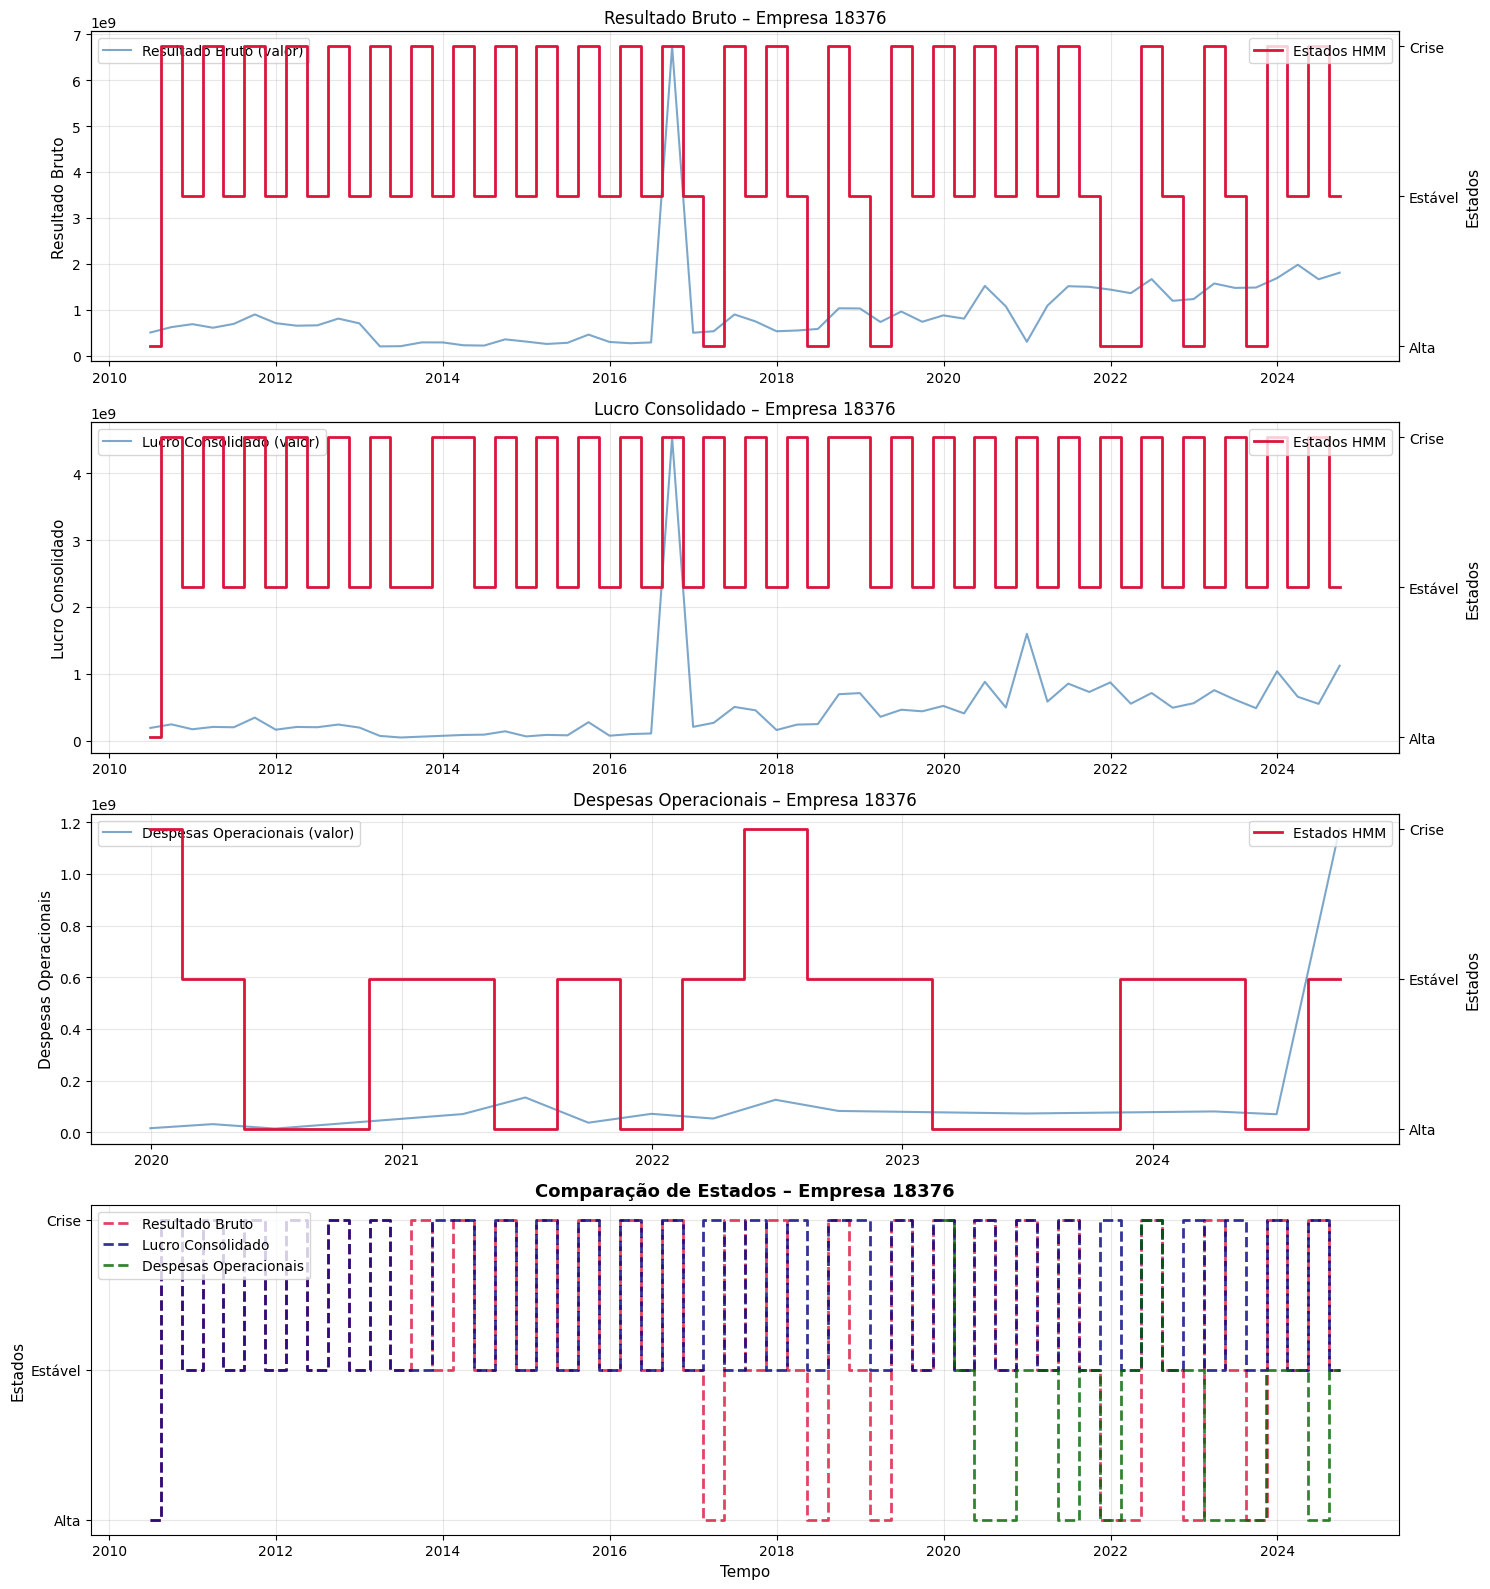


RESUMO DOS MODELOS HMM

Resultado Bruto:
  Convergiu: True
  Log-Likelihood: -59.51
  Número de observações: 58

  Matriz de Transição:
[[0.152 0.    0.848]
 [0.259 0.036 0.704]
 [0.002 0.997 0.001]]

  Matriz de Emissão:
[[0.145 0.855 0.   ]
 [0.406 0.463 0.131]
 [0.352 0.    0.647]]

Lucro Consolidado:
  Convergiu: True
  Log-Likelihood: -54.17
  Número de observações: 56

  Matriz de Transição:
[[0.    0.001 0.999]
 [0.004 0.001 0.995]
 [0.015 0.932 0.053]]

  Matriz de Emissão:
[[0.    1.    0.   ]
 [0.599 0.295 0.106]
 [0.118 0.31  0.572]]

Despesas Operacionais:
  Convergiu: True
  Log-Likelihood: -13.11
  Número de observações: 14

  Matriz de Transição:
[[0.    1.    0.   ]
 [0.832 0.    0.168]
 [0.    1.    0.   ]]

  Matriz de Emissão:
[[0.4   0.6   0.   ]
 [0.429 0.143 0.429]
 [0.002 0.001 0.996]]


In [40]:
empresa_analise = '18376'

indicadores = {
    'Resultado Bruto': resultado_bruto[empresa_analise],
    'Lucro Consolidado': lucro_consolidado[empresa_analise],
    'Despesas Operacionais': despesas_operacionais[empresa_analise]
}

# Executa análise
resultados_hmm = analisar_multiplos_indicadores_hmm(
    empresa=empresa_analise,
    indicadores_dict=indicadores,
    n_estados=3,
    n_bins=3,
    n_iter=100
)

# Plota comparação
plotar_comparacao_estados(resultados_hmm, empresa_analise, n_estados=3)

# Exibe resumo
resumo_modelos(resultados_hmm)

### Comparação dos estados do mesmo indicador em 3 empresas

In [ ]:
def analisar_indicador_multiplas_empresas(empresas_list, indicador_series, nome_indicador, n_estados=3, n_bins=2, n_iter=100, retornar_coincidencias=False):
    """
    Treina modelos HMM para o mesmo indicador em múltiplas empresas e compara estados.
    
    Args:
        empresas_list: lista de códigos das empresas
        indicador_series: DataFrame ou dict com séries do indicador por empresa
        nome_indicador: nome do indicador (ex: 'Resultado Bruto')
        n_estados: número de estados ocultos
        n_bins: número de bins para discretização
        n_iter: iterações do Baum-Welch
    
    Returns:
        dict com modelos, estados e séries processadas por empresa
    """
    resultados = {}
    
    for empresa in empresas_list:
        print(f"\n--- Processando Empresa {empresa} ---")
        
        # Obtém série da empresa
        if isinstance(indicador_series, pd.DataFrame):
            serie = indicador_series[empresa]
        else:
            serie = indicador_series[empresa]
        
        # Prepara série
        serie_limpa = (
            serie
            .sort_index()
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        
        # Usa pct_change para suportar valores negativos (log-returns falham com valores <= 0)
        serie_ret = (
            serie_limpa
            .pct_change()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        
        obs_sequencia = discretiza_kmeans(
            serie_limpa,
            bins=n_bins,
            tipo_clusterizacao='quantile',
            tipo_discretizacao='pct_change'  # pct_change suporta valores negativos
        )
        
        # Treina modelo
        model = hmm.CategoricalHMM(
            n_components=n_estados,
            n_iter=n_iter,
            random_state=1
        )
        model.fit(obs_sequencia)
        
        # Decodifica estados
        _, estados_preditos = model.decode(obs_sequencia)
        
        # Armazena resultados
        resultados[empresa] = {
            'serie_original': serie_limpa,
            'serie_pct': serie_ret,
            'estados': estados_preditos,
            'index': serie_ret.index,
            'modelo': model,
            'convergiu': model.monitor_.converged,
            'log_likelihood': model.monitor_.history[-1] if model.monitor_.history else np.nan
        }
        
        print(f"Convergiu: {model.monitor_.converged}")
        print(f"Log-Likelihood: {model.monitor_.history[-1]:.2f}" if model.monitor_.history else "N/A")
        print(f"Número de observações: {len(estados_preditos)}")
    
    if retornar_coincidencias:
        return resultados, _coincidencias_todas_empresas(resultados)
    return resultados

def plotar_comparacao_empresas(resultados, nome_indicador, n_estados=3):
    """
    Plota comparação dos estados do mesmo indicador entre múltiplas empresas.
    
    Args:
        resultados: dict retornado por analisar_indicador_multiplas_empresas
        nome_indicador: nome do indicador
        n_estados: número de estados para labels
    """
    n_empresas = len(resultados)
    fig, axes = plt.subplots(n_empresas + 1, 1, figsize=(15, 4 * (n_empresas + 1)))
    
    if n_empresas == 1:
        axes = [axes]
    
    # Plot individual de cada empresa
    for i, (empresa, dados) in enumerate(resultados.items()):
        ax = axes[i]
        ax.plot(dados['index'], dados['serie_original'].loc[dados['index']], 
                color='steelblue', label=f'{nome_indicador} (valor)', alpha=0.7)
        ax.set_ylabel(nome_indicador, fontsize=11)
        ax.set_title(f'{nome_indicador} – Empresa {empresa}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
        
        # Eixo secundário para estados
        ax2 = ax.twinx()
        ax2.step(dados['index'], dados['estados'], where='mid', 
                 color='crimson', label='HMM States', linewidth=2)
        ax2.set_ylabel('States', fontsize=11)
        
        if n_estados == 2:
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels(['Positive', 'Negative'])
        elif n_estados == 3:
            ax2.set_yticks([0, 1, 2])
            ax2.set_yticklabels(['High', 'Stable', 'Crisis'])
        else:
            ax2.set_yticks(range(n_estados))
        
        ax2.legend(loc='upper right')
    
    # Plot comparativo (último subplot)
    ax_comp = axes[-1]
    cores = ['crimson', 'navy', 'darkgreen', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    for idx, (empresa, dados) in enumerate(resultados.items()):
        ax_comp.step(dados['index'], dados['estados'], where='mid',
                     label=f'Empresa {empresa}', linewidth=2, 
                     color=cores[idx % len(cores)], alpha=0.8, linestyle='--')
    
    ax_comp.set_title(f'State Comparison: {nome_indicador} – Multiple Companies', 
                      fontsize=13, fontweight='bold')
    ax_comp.set_xlabel('Time', fontsize=11)
    ax_comp.set_ylabel('States', fontsize=11)
    
    if n_estados == 2:
        ax_comp.set_yticks([0, 1])
        ax_comp.set_yticklabels(['Positive', 'Negative'])
    elif n_estados == 3:
        ax_comp.set_yticks([0, 1, 2])
        ax_comp.set_yticklabels(['High', 'Stable', 'Crisis'])
    else:
        ax_comp.set_yticks(range(n_estados))
    
    ax_comp.legend(loc='upper left', fontsize=10, ncol=2)
    ax_comp.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def resumo_modelos_empresas(resultados, nome_indicador):
    """Exibe resumo dos modelos treinados por empresa"""
    print("\n" + "="*60)
    print(f"RESUMO DOS MODELOS HMM - {nome_indicador}")
    print("="*60)
    
    for empresa, dados in resultados.items():
        print(f"\nEmpresa {empresa}:")
        print(f"  Convergiu: {dados['convergiu']}")
        print(f"  Log-Likelihood: {dados['log_likelihood']:.2f}")
        print(f"  Número de observações: {len(dados['estados'])}")
        print(f"\n  Matriz de Transição:")
        print(dados['modelo'].transmat_.round(3))
        print(f"\n  Matriz de Emissão:")
        print(dados['modelo'].emissionprob_.round(3))


In [61]:
def _coincidencias_todas_empresas(resultados):
    """Conta coincidências de estados em TODAS as empresas simultaneamente."""
    if not resultados:
        return pd.DataFrame()

    empresas = list(resultados.keys())
    # Interseção de índices em comum entre todas as empresas
    idx_comum = resultados[empresas[0]]['index']
    for e in empresas[1:]:
        idx_comum = idx_comum.intersection(resultados[e]['index'])

    if len(idx_comum) == 0:
        return pd.DataFrame([{
            'observacoes_comuns': 0,
            'coincidencias_todas': 0,
            'percentual_coincidencia_todas': np.nan
        }])

    # Monta matriz estados (linhas = tempo, cols = empresa)
    estados_df = pd.DataFrame({
        emp: pd.Series(resultados[emp]['estados'], index=resultados[emp]['index']).loc[idx_comum].values
        for emp in empresas
    }, index=idx_comum)

    # Coincidência somente quando todas as empresas estão no mesmo estado
    mask_coinc = estados_df.apply(lambda row: len(set(row)) == 1, axis=1)
    coincidencias_todas = mask_coinc.sum()

    # Quebra por estado: conta quantas vezes todas coincidiram no mesmo estado k
    valores_estados = np.unique(estados_df.values)
    coincidencias_por_estado = {
        int(k): int(((estados_df == k).all(axis=1)).sum()) for k in valores_estados
    }

    return pd.DataFrame([{
        'observacoes_comuns': len(idx_comum),
        'coincidencias_todas': coincidencias_todas,
        'percentual_coincidencia_todas': coincidencias_todas / len(idx_comum),
        'coincidencias_por_estado': coincidencias_por_estado
    }])


--- Processando Empresa 21490 ---
Bordas dos Bins (K-Means):
[-5.02119721 -0.6214101   0.07020843  9.08240768]
Convergiu: True
Log-Likelihood: -54.13
Número de observações: 58

--- Processando Empresa 2437 ---
Bordas dos Bins (K-Means):
[-22.79912181  -0.2611166    0.167829    23.24329878]
Convergiu: True
Log-Likelihood: -58.14
Número de observações: 58

--- Processando Empresa 20257 ---
Bordas dos Bins (K-Means):
[-12.51751983  -0.54353459   0.12777257  36.91949744]
Convergiu: True
Log-Likelihood: -60.34
Número de observações: 58

--- Processando Empresa 18376 ---
Bordas dos Bins (K-Means):
[-48.9741594   -1.19259786  -0.10029856  15.7261093 ]
Convergiu: True
Log-Likelihood: -58.43
Número de observações: 58
   observacoes_comuns  coincidencias_todas  percentual_coincidencia_todas  \
0                  58                    8                       0.137931   

  coincidencias_por_estado  
0       {0: 1, 1: 3, 2: 4}  


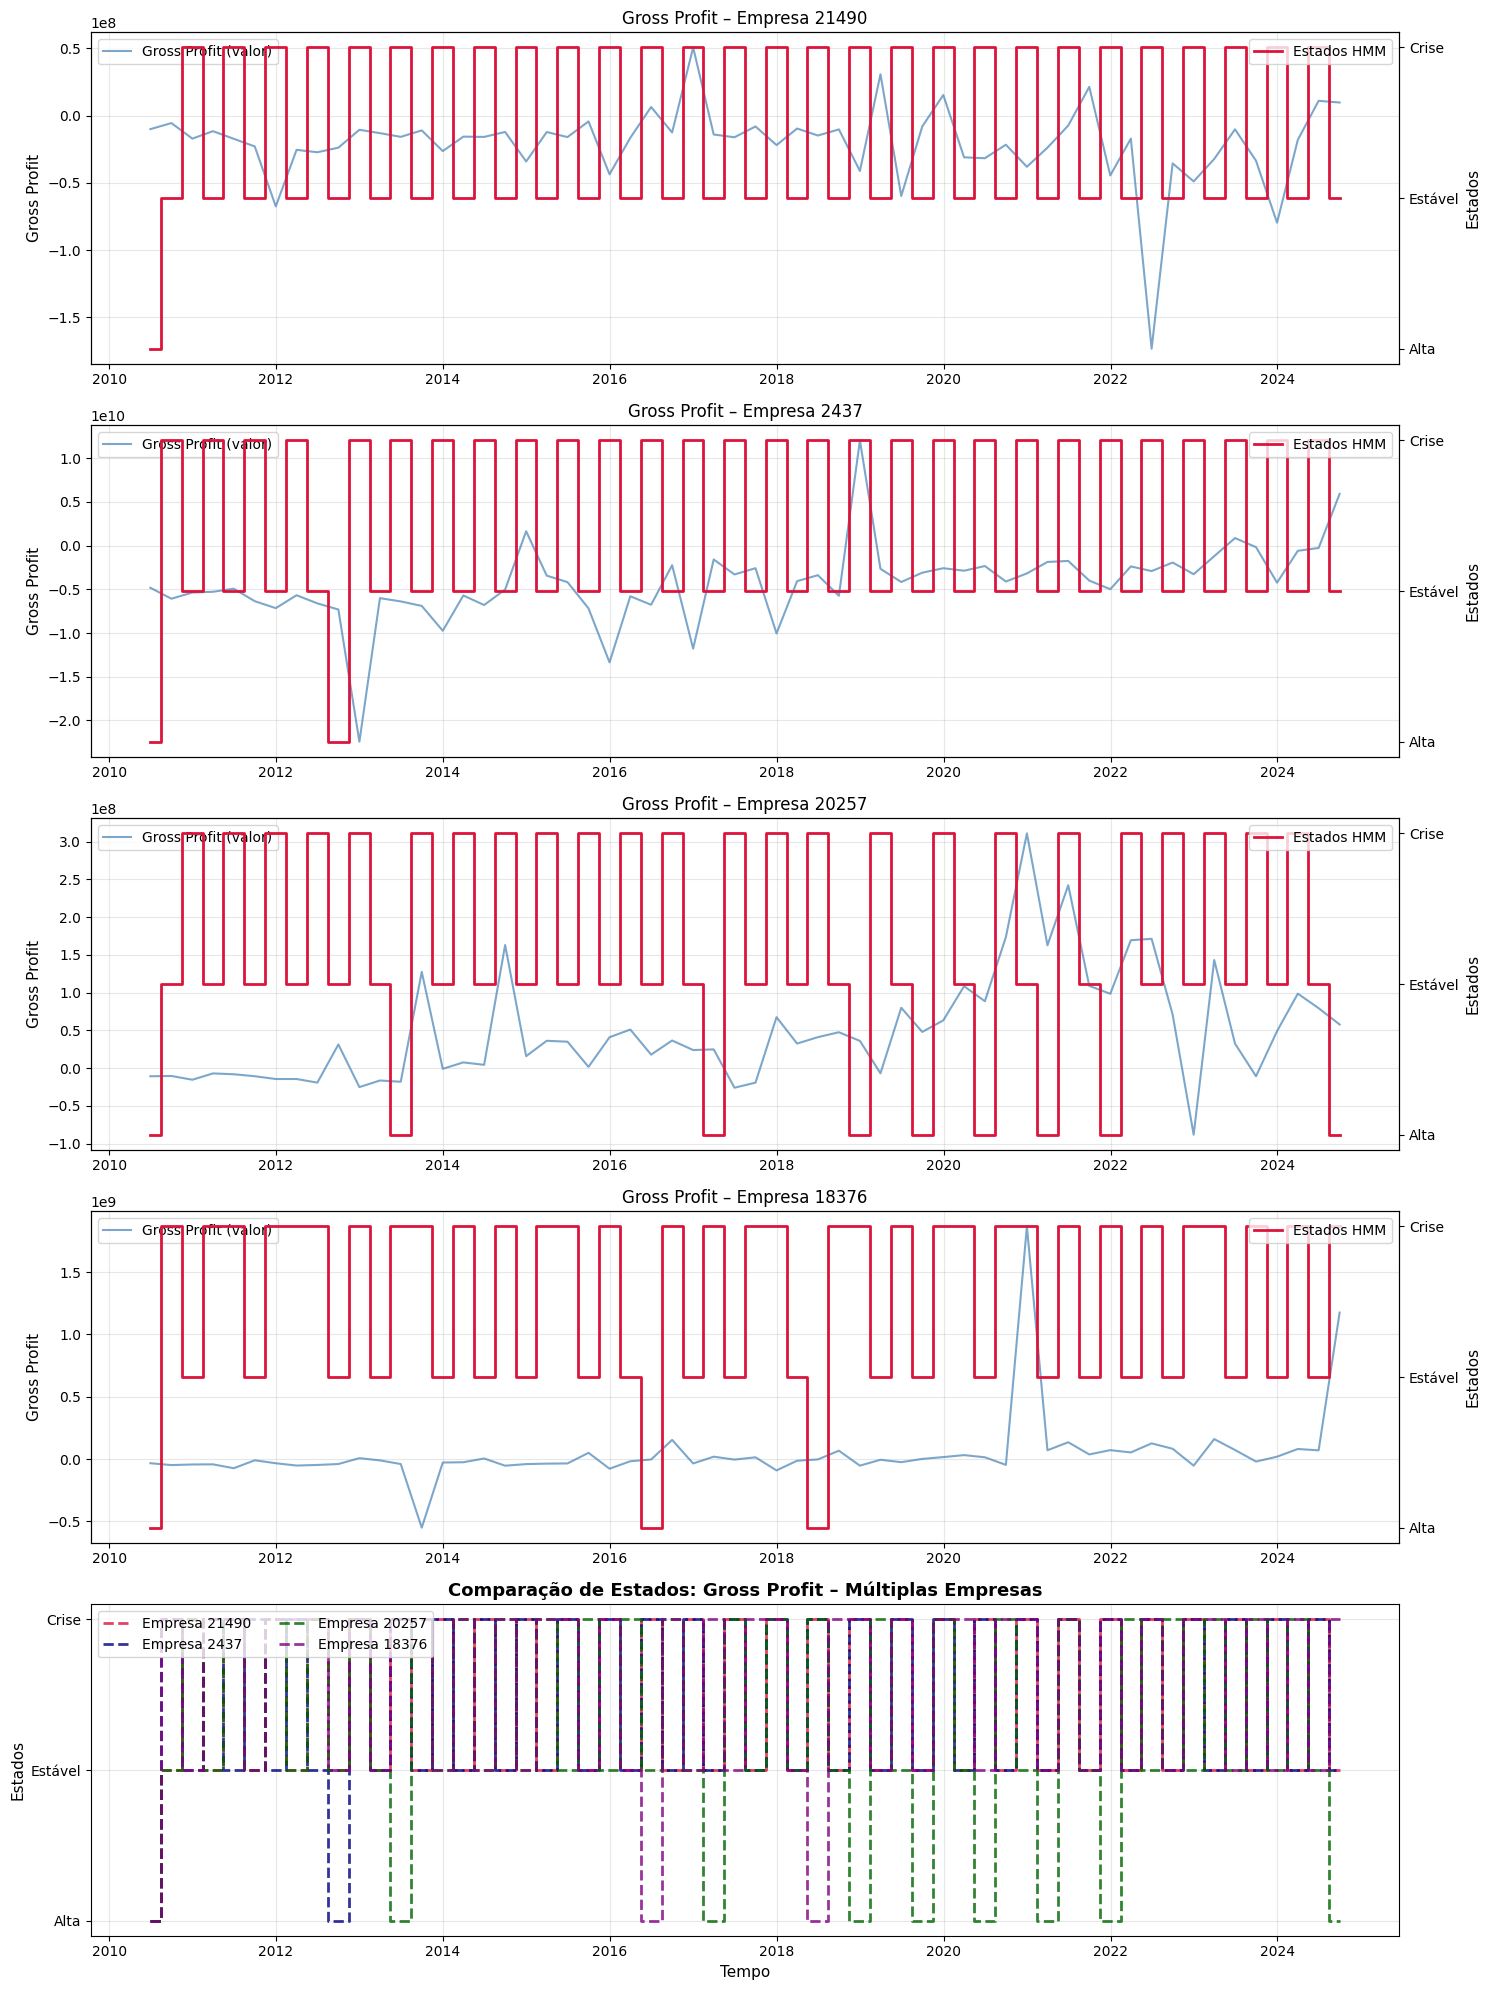


RESUMO DOS MODELOS HMM - Gross Profit

Empresa 21490:
  Convergiu: True
  Log-Likelihood: -54.13
  Número de observações: 58

  Matriz de Transição:
[[0.    1.    0.   ]
 [0.031 0.    0.969]
 [0.    1.    0.   ]]

  Matriz de Emissão:
[[0.003 0.997 0.   ]
 [0.379 0.517 0.103]
 [0.295 0.115 0.59 ]]

Empresa 2437:
  Convergiu: True
  Log-Likelihood: -58.14
  Número de observações: 58

  Matriz de Transição:
[[0.002 0.019 0.979]
 [0.041 0.    0.959]
 [0.003 0.997 0.   ]]

  Matriz de Emissão:
[[0.    1.    0.   ]
 [0.537 0.314 0.15 ]
 [0.144 0.325 0.531]]

Empresa 20257:
  Convergiu: True
  Log-Likelihood: -60.34
  Número de observações: 58

  Matriz de Transição:
[[0.    0.338 0.662]
 [0.32  0.    0.68 ]
 [0.001 0.999 0.   ]]

  Matriz de Emissão:
[[0.    1.    0.   ]
 [0.419 0.378 0.204]
 [0.401 0.    0.599]]

Empresa 18376:
  Convergiu: True
  Log-Likelihood: -58.43
  Número de observações: 58

  Matriz de Transição:
[[0.    0.    1.   ]
 [0.149 0.    0.851]
 [0.033 0.574 0.393]]

  M

In [75]:
# Uso da função
empresas_analise = ['21490', '2437', '20257', '18376']  # Liste as empresas desejadas

despesas_operacionais_empresas, coincidencias_empresas_despesas = analisar_indicador_multiplas_empresas(
   empresas_list=empresas_analise,
   indicador_series=despesas_operacionais,
   nome_indicador='Gross Income',
   n_estados=3,
   n_bins=3,
   n_iter=100, 
   retornar_coincidencias=True
)

print(coincidencias_empresas_despesas)

plotar_comparacao_empresas(despesas_operacionais_empresas, 'Gross Profit', n_estados=3)
resumo_modelos_empresas(despesas_operacionais_empresas, 'Gross Profit')


In [77]:
_coincidencias_todas_empresas(despesas_operacionais_empresas)

,observacoes_comuns,coincidencias_todas,percentual_coincidencia_todas,coincidencias_por_estado
0,58,8,0.137931,"{0: 1, 1: 3, 2: 4}"


In [79]:
print(coincidencias_empresas_despesas)

   observacoes_comuns  coincidencias_todas  percentual_coincidencia_todas  \
0                  58                    8                       0.137931   

  coincidencias_por_estado  
0       {0: 1, 1: 3, 2: 4}  


## Coincidência de Estados Entre Indicadores (mesma empresa)

In [ ]:
def analisar_coincidencia_indicadores_empresa(empresa, indicadores_dict, n_estados=3, n_bins=3, n_iter=100):
    """
    Treina um HMM para cada indicador de uma mesma empresa e calcula
    a coincidência de estados entre os indicadores ao longo do tempo.

    Args:
        empresa         : código da empresa (str ou int)
        indicadores_dict: dict { nome_indicador -> DataFrame/Series com coluna/chave = empresa }
        n_estados       : número de estados ocultos do HMM
        n_bins          : número de bins para discretização
        n_iter          : iterações do Baum-Welch

    Returns:
        resultados      : dict { nome_indicador -> { serie_original, serie_pct, estados, index, modelo, ... } }
        coincidencias   : DataFrame com estatísticas de coincidência par-a-par e global
    """
    resultados = {}

    for nome_ind, serie_fonte in indicadores_dict.items():
        print(f"\n--- Indicador: {nome_ind} | Empresa: {empresa} ---")

        # Extrai a série da empresa
        if isinstance(serie_fonte, pd.DataFrame):
            if empresa not in serie_fonte.columns:
                print(f"  [AVISO] Empresa {empresa} não encontrada em '{nome_ind}'. Pulando.")
                continue
            serie = serie_fonte[empresa]
        else:
            serie = pd.Series(serie_fonte)

        # Limpeza
        serie_limpa = (
            serie
            .sort_index()
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(serie_limpa) < n_bins + 2:
            print(f"  [AVISO] Série muito curta ({len(serie_limpa)} obs). Pulando.")
            continue

        # Retorno percentual (suporta valores negativos)
        serie_ret = (
            serie_limpa
            .pct_change()
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        obs_sequencia = discretiza_kmeans(
            serie_limpa,
            bins=n_bins,
            tipo_clusterizacao='quantile',
            tipo_discretizacao='pct_change'
        )

        # Treina HMM
        model = hmm.CategoricalHMM(n_components=n_estados, n_iter=n_iter, random_state=1)
        model.fit(obs_sequencia)
        _, estados_preditos = model.decode(obs_sequencia)

        resultados[nome_ind] = {
            'serie_original': serie_limpa,
            'serie_pct'     : serie_ret,
            'estados'       : estados_preditos,
            'index'         : serie_ret.index,
            'modelo'        : model,
            'convergiu'     : model.monitor_.converged,
            'log_likelihood': model.monitor_.history[-1] if model.monitor_.history else np.nan,
        }
        print(f"  Convergiu: {model.monitor_.converged} | Obs: {len(estados_preditos)}")

    coincidencias = _coincidencias_indicadores(resultados)
    return resultados, coincidencias


def _coincidencias_indicadores(resultados):
    """
    Calcula coincidências de estados par-a-par e global entre indicadores.

    Returns:
        DataFrame com uma linha por par de indicadores + uma linha 'TODOS'
    """
    nomes = list(resultados.keys())
    if len(nomes) < 2:
        return pd.DataFrame()

    linhas = []

    # --- Par-a-par ---
    for i in range(len(nomes)):
        for j in range(i + 1, len(nomes)):
            ind_a, ind_b = nomes[i], nomes[j]
            idx_comum = resultados[ind_a]['index'].intersection(resultados[ind_b]['index'])

            if len(idx_comum) == 0:
                linhas.append({
                    'par': f'{ind_a} × {ind_b}',
                    'observacoes_comuns': 0,
                    'coincidencias': 0,
                    'percentual': np.nan,
                    'coincidencias_por_estado': {}
                })
                continue

            s_a = pd.Series(resultados[ind_a]['estados'], index=resultados[ind_a]['index']).loc[idx_comum]
            s_b = pd.Series(resultados[ind_b]['estados'], index=resultados[ind_b]['index']).loc[idx_comum]

            mask = s_a.values == s_b.values
            n_coinc = mask.sum()

            estados_unidos = np.unique(np.concatenate([s_a.values, s_b.values]))
            por_estado = {int(k): int(((s_a.values == k) & (s_b.values == k)).sum()) for k in estados_unidos}

            linhas.append({
                'par': f'{ind_a} × {ind_b}',
                'observacoes_comuns': len(idx_comum),
                'coincidencias': n_coinc,
                'percentual': n_coinc / len(idx_comum),
                'coincidencias_por_estado': por_estado
            })

    # --- Todos os indicadores simultaneamente ---
    idx_global = resultados[nomes[0]]['index']
    for n in nomes[1:]:
        idx_global = idx_global.intersection(resultados[n]['index'])

    if len(idx_global) > 0:
        estados_df = pd.DataFrame({
            n: pd.Series(resultados[n]['estados'], index=resultados[n]['index']).loc[idx_global].values
            for n in nomes
        }, index=idx_global)

        mask_todos = estados_df.apply(lambda row: len(set(row)) == 1, axis=1)
        n_coinc_todos = mask_todos.sum()
        estados_u = np.unique(estados_df.values)
        por_estado_todos = {int(k): int(((estados_df == k).all(axis=1)).sum()) for k in estados_u}

        linhas.append({
            'par': 'TODOS',
            'observacoes_comuns': len(idx_global),
            'coincidencias': n_coinc_todos,
            'percentual': n_coinc_todos / len(idx_global),
            'coincidencias_por_estado': por_estado_todos
        })

    return pd.DataFrame(linhas)


def plotar_coincidencia_indicadores(resultados, empresa, n_estados=3):
    """
    Plota os estados HMM de cada indicador para uma empresa,
    facilitando a visualização visual das coincidências.

    Args:
        resultados: dict retornado por analisar_coincidencia_indicadores_empresa
        empresa   : código da empresa (apenas para o título)
        n_estados : número de estados (para labels no eixo Y)
    """
    nomes = list(resultados.keys())
    n = len(nomes)
    if n == 0:
        print("Nenhum resultado para plotar.")
        return

    fig, axes = plt.subplots(n, 1, figsize=(15, 3.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    cores = ['crimson', 'navy', 'darkgreen', 'purple', 'darkorange', 'brown']
    yticks = list(range(n_estados))
    ylabels_map = {2: ['Positive', 'Negative'], 3: ['High', 'Stable', 'Crisis']}
    ylabels = ylabels_map.get(n_estados, [str(k) for k in yticks])

    for i, nome in enumerate(nomes):
        ax = axes[i]
        dados = resultados[nome]
        cor = cores[i % len(cores)]

        # Série original no eixo primário
        ax.plot(
            dados['index'],
            dados['serie_original'].loc[dados['index']],
            color='steelblue', alpha=0.5, linewidth=1.2, label=f'{nome} (valor)'
        )
        ax.set_ylabel(nome, fontsize=10)
        ax.set_title(f'{nome} – Empresa {empresa}', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', fontsize=9)

        # Estados no eixo secundário
        ax2 = ax.twinx()
        ax2.step(dados['index'], dados['estados'], where='mid',
                 color=cor, linewidth=2, label='Estado HMM')
        ax2.set_yticks(yticks)
        ax2.set_yticklabels(ylabels, fontsize=8)
        ax2.set_ylabel('State', fontsize=9)
        ax2.legend(loc='upper right', fontsize=9)

    axes[-1].set_xlabel('Time', fontsize=11)
    plt.suptitle(f'HMM States by Indicator – Company {empresa}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()



--- Indicador: Gross Income | Empresa: 21490 ---
Bordas dos Bins (K-Means):
[-0.50460942 -0.05541798  0.07601499  1.84235268]
  Convergiu: True | Obs: 58

--- Indicador: Lucro Consolidado | Empresa: 21490 ---
Bordas dos Bins (K-Means):
[-0.78030117 -0.09062198  0.14533615  8.74542798]
  Convergiu: True | Obs: 58

--- Indicador: Despesas Operacionais | Empresa: 21490 ---
Bordas dos Bins (K-Means):
[-5.02119721 -0.6214101   0.07020843  9.08240768]
  Convergiu: True | Obs: 58
                                      par  observacoes_comuns  coincidencias  percentual coincidencias_por_estado
         Gross Income × Lucro Consolidado                  58             32    0.551724     {0: 7, 1: 11, 2: 14}
     Gross Income × Despesas Operacionais                  58             21    0.362069     {0: 1, 1: 10, 2: 10}
Lucro Consolidado × Despesas Operacionais                  58             22    0.379310     {0: 1, 1: 10, 2: 11}
                                    TODOS                  58    

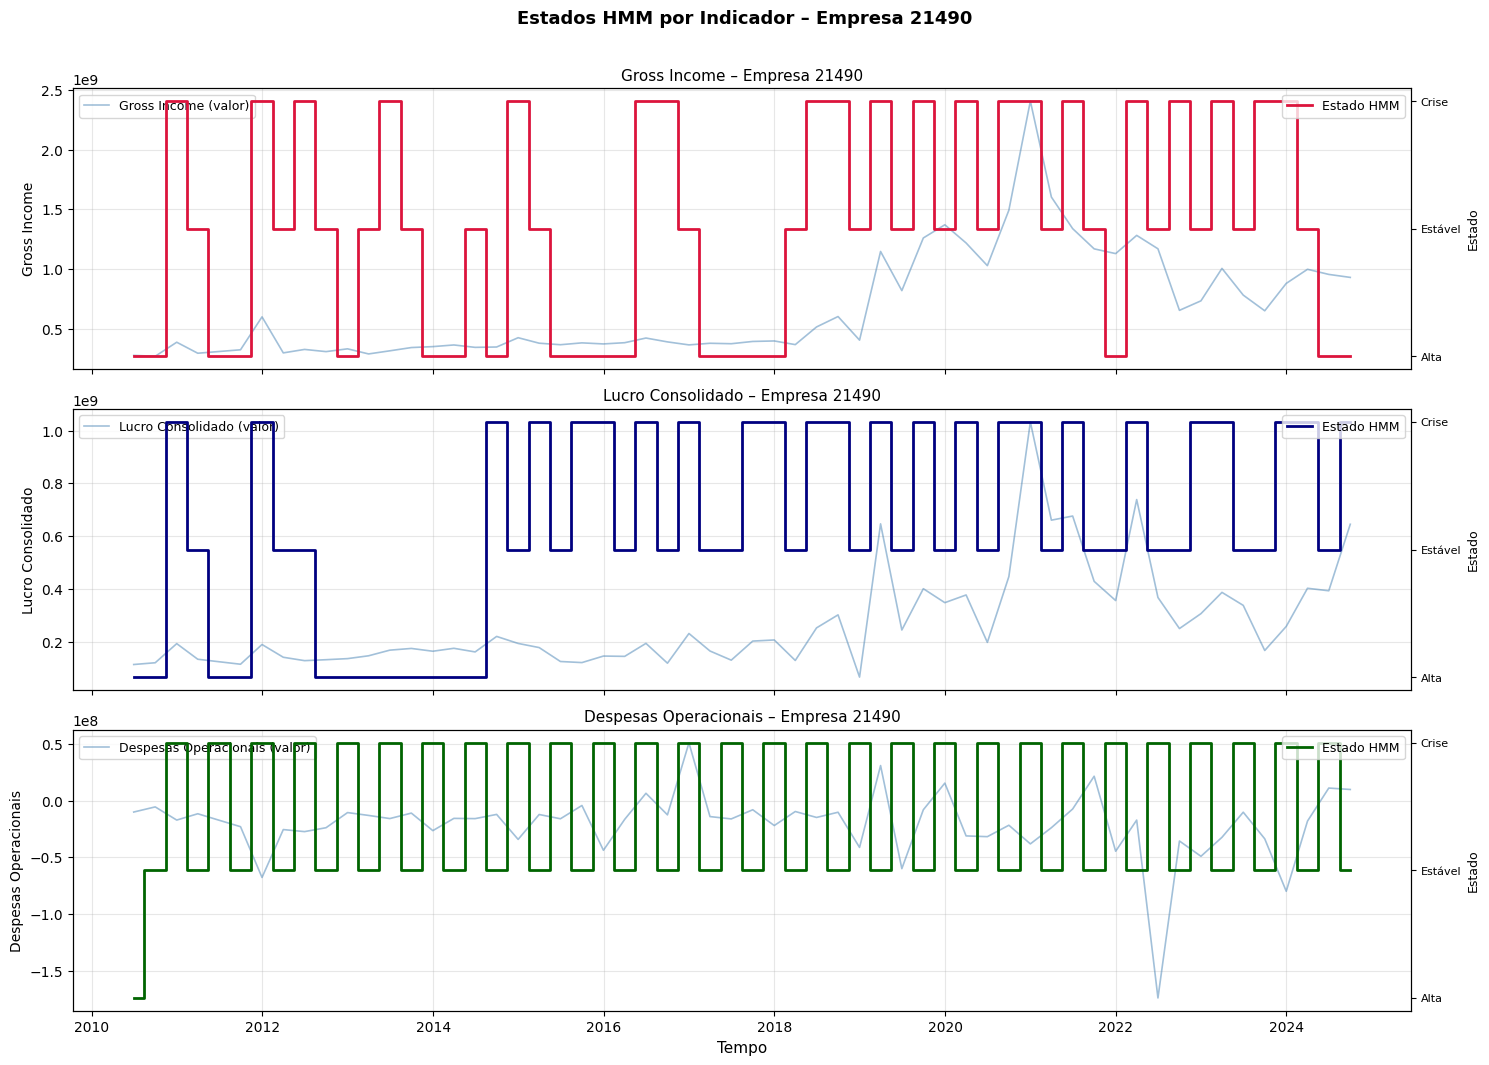

In [88]:
# Exemplo de uso — coincidência de estados entre indicadores para uma mesma empresa
empresa_alvo = '21490'

# Monta dict com os indicadores desejados { nome -> DataFrame com coluna por empresa }
indicadores_empresa = {
    'Gross Income'          : resultado_bruto,
    'Lucro Consolidado'     : lucro_consolidado,
    'Despesas Operacionais' : despesas_operacionais,
}

resultados_ind, coincidencias_ind = analisar_coincidencia_indicadores_empresa(
    empresa=empresa_alvo,
    indicadores_dict=indicadores_empresa,
    n_estados=3,
    n_bins=3,
    n_iter=100
)

print(coincidencias_ind.to_string(index=False))

plotar_coincidencia_indicadores(resultados_ind, empresa=empresa_alvo, n_estados=3)


## Visualização das PMFs (Probability Mass Functions)

In [ ]:
def plotar_pmf_individual(modelo, nome_indicador, n_bins=3, n_estados=3, bins_labels=None):
    """
    Plota a PMF (matriz de emissão) de um único modelo HMM.
    
    Args:
        modelo: objeto CategoricalHMM treinado
        nome_indicador: nome do indicador para o título
        n_bins: número de bins usados na discretização
        n_estados: número de estados ocultos
        bins_labels: lista com rótulos personalizados para os bins
    """
    emissionprob = modelo.emissionprob_
    
    # Labels padrão
    if bins_labels is None:
        if n_bins == 2:
            bins_labels = ['Positive', 'Negative']
        elif n_bins == 3:
            bins_labels = ['High (+)', 'Stable (0)', 'Low (-)']
        elif n_bins == 4:
            bins_labels = ['Very High', 'High', 'Low', 'Very Low']
        elif n_bins == 5:
            bins_labels = ['Very High', 'High', 'Stable', 'Low', 'Very Low']
        else:
            bins_labels = [f'Bin {i}' for i in range(n_bins)]
    
    estados_labels = [f'State {i}' for i in range(n_estados)]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Heatmap da matriz de emissão
    im = axes[0].imshow(emissionprob, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    axes[0].set_xticks(range(n_bins))
    axes[0].set_xticklabels(bins_labels, rotation=45, ha='right')
    axes[0].set_yticks(range(n_estados))
    axes[0].set_yticklabels(estados_labels)
    axes[0].set_xlabel('Observations (Bins)', fontsize=11)
    axes[0].set_ylabel('Hidden States', fontsize=11)
    axes[0].set_title(f'Emission Matrix - {nome_indicador}\n(Probability of each observation given the state)', 
                     fontsize=12, fontweight='bold')
    
    # Adiciona valores numéricos nas células
    for i in range(n_estados):
        for j in range(n_bins):
            text = axes[0].text(j, i, f'{emissionprob[i, j]:.3f}',
                              ha="center", va="center", color="black", fontsize=9)
    
    plt.colorbar(im, ax=axes[0], label='Probabilidade')
    
    # 2. Barras agrupadas - PMF por estado
    x = np.arange(n_bins)
    width = 0.8 / n_estados
    cores = plt.cm.Set2(np.linspace(0, 1, n_estados))
    
    for i in range(n_estados):
        offset = (i - n_estados/2 + 0.5) * width
        axes[1].bar(x + offset, emissionprob[i, :], width, 
                   label=estados_labels[i], alpha=0.8, color=cores[i], edgecolor='black')
    
    axes[1].set_xlabel('Observations (Bins)', fontsize=11)
    axes[1].set_ylabel('Probability', fontsize=11)
    axes[1].set_title(f'PMF by State - {nome_indicador}\nP(Observation | State)', 
                     fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(bins_labels, rotation=45, ha='right')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


def plotar_pmf_comparacao_multiplos(resultados, n_bins=3, n_estados=3, bins_labels=None):
    """
    Plota comparação das PMFs de múltiplos indicadores lado a lado.
    
    Args:
        resultados: dict retornado por analisar_multiplos_indicadores_hmm
        n_bins: número de bins usados
        n_estados: número de estados
        bins_labels: lista com rótulos personalizados para os bins
    """
    n_indicadores = len(resultados)
    
    # Labels padrão
    if bins_labels is None:
        if n_bins == 2:
            bins_labels = ['Positive', 'Negative']
        elif n_bins == 3:
            bins_labels = ['High (+)', 'Stable (0)', 'Low (-)']
        elif n_bins == 4:
            bins_labels = ['Very High', 'High', 'Low', 'Very Low']
        elif n_bins == 5:
            bins_labels = ['Very High', 'High', 'Stable', 'Low', 'Very Low']
        else:
            bins_labels = [f'Bin {i}' for i in range(n_bins)]
    
    estados_labels = [f'State {i}' for i in range(n_estados)]
    
    # Create subplot grid
    fig, axes = plt.subplots(n_indicadores, 2, figsize=(16, 5 * n_indicadores))
    
    if n_indicadores == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (nome, dados) in enumerate(resultados.items()):
        modelo = dados['modelo']
        emissionprob = modelo.emissionprob_
        
        # Coluna 1: Heatmap
        ax_heat = axes[idx, 0]
        im = ax_heat.imshow(emissionprob, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        ax_heat.set_xticks(range(n_bins))
        ax_heat.set_xticklabels(bins_labels, rotation=45, ha='right')
        ax_heat.set_yticks(range(n_estados))
        ax_heat.set_yticklabels(estados_labels)
        ax_heat.set_xlabel('Observations (Bins)', fontsize=10)
        ax_heat.set_ylabel('Hidden States', fontsize=10)
        ax_heat.set_title(f'{nome}\nEmission Matrix', fontsize=11, fontweight='bold')
        
        # Adiciona valores numéricos
        for i in range(n_estados):
            for j in range(n_bins):
                ax_heat.text(j, i, f'{emissionprob[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)
        
        plt.colorbar(im, ax=ax_heat, label='P(Obs|Estado)', fraction=0.046, pad=0.04)
        
        # Coluna 2: Barras agrupadas
        ax_bar = axes[idx, 1]
        x = np.arange(n_bins)
        width = 0.8 / n_estados
        cores = plt.cm.Set2(np.linspace(0, 1, n_estados))
        
        for i in range(n_estados):
            offset = (i - n_estados/2 + 0.5) * width
            ax_bar.bar(x + offset, emissionprob[i, :], width, 
                      label=estados_labels[i], alpha=0.8, color=cores[i], edgecolor='black')
        
        ax_bar.set_xlabel('Observations (Bins)', fontsize=10)
        ax_bar.set_ylabel('Probability', fontsize=10)
        ax_bar.set_title(f'{nome}\nPMF by State', fontsize=11, fontweight='bold')
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(bins_labels, rotation=45, ha='right')
        ax_bar.legend(loc='upper right', fontsize=8)
        ax_bar.grid(True, alpha=0.3, axis='y')
        ax_bar.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


def plotar_pmf_estado_especifico(resultados, estado=0, n_bins=3, bins_labels=None):
    """
    Compara a PMF de um estado específico entre diferentes indicadores.
    
    Args:
        resultados: dict retornado por analisar_multiplos_indicadores_hmm
        estado: qual estado comparar (0, 1, 2, etc.)
        n_bins: número de bins
        bins_labels: rótulos dos bins
    """
    if bins_labels is None:
        if n_bins == 2:
            bins_labels = ['Positive', 'Negative']
        elif n_bins == 3:
            bins_labels = ['High (+)', 'Stable (0)', 'Low (-)']
        else:
            bins_labels = [f'Bin {i}' for i in range(n_bins)]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(n_bins)
    width = 0.8 / len(resultados)
    cores = plt.cm.Set3(np.linspace(0, 1, len(resultados)))
    
    for idx, (nome, dados) in enumerate(resultados.items()):
        emissionprob = dados['modelo'].emissionprob_
        offset = (idx - len(resultados)/2 + 0.5) * width
        ax.bar(x + offset, emissionprob[estado, :], width, 
               label=nome, alpha=0.8, color=cores[idx], edgecolor='black')
        
        # Adiciona valores no topo das barras
        for i, v in enumerate(emissionprob[estado, :]):
            ax.text(x[i] + offset, v + 0.02, f'{v:.2f}', 
                   ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Observations (Bins)', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'PMF Comparison - State {estado}\nP(Observation | State={estado})', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bins_labels, rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max([dados['modelo'].emissionprob_[estado, :].max() for dados in resultados.values()]) + 0.1)
    
    plt.tight_layout()
    plt.show()


def resumo_pmf_textual(resultados, n_bins=3, bins_labels=None):
    """
    Exibe resumo textual das PMFs com interpretação.
    
    Args:
        resultados: dict retornado por analisar_multiplos_indicadores_hmm
        n_bins: número de bins
        bins_labels: rótulos dos bins
    """
    if bins_labels is None:
        if n_bins == 2:
            bins_labels = ['Positivo', 'Negativo']
        elif n_bins == 3:
            bins_labels = ['Alta (+)', 'Estável (0)', 'Baixa (-)']
        else:
            bins_labels = [f'Bin {i}' for i in range(n_bins)]
    
    print("\n" + "="*70)
    print("ANÁLISE DAS PMFs (MATRIZES DE EMISSÃO)")
    print("="*70)
    
    for nome, dados in resultados.items():
        modelo = dados['modelo']
        emissionprob = modelo.emissionprob_
        n_estados = emissionprob.shape[0]
        
        print(f"\n{'─'*70}")
        print(f"📊 {nome}")
        print(f"{'─'*70}")
        
        for estado in range(n_estados):
            print(f"\n  Estado {estado}:")
            probs = emissionprob[estado, :]
            
            # Mostra probabilidades
            for bin_idx, (label, prob) in enumerate(zip(bins_labels, probs)):
                barra = '█' * int(prob * 20)
                print(f"    {label:20s}: {prob:.3f} {barra}")
            
            # Interpretação: qual observação é mais provável neste estado?
            bin_mais_provavel = np.argmax(probs)
            prob_max = probs[bin_mais_provavel]
            print(f"    → Mais provável: {bins_labels[bin_mais_provavel]} ({prob_max:.1%})")
            
            # Verifica se há incerteza (distribuição uniforme)
            entropia = -np.sum(probs * np.log(probs + 1e-10))
            entropia_max = np.log(n_bins)
            incerteza = entropia / entropia_max
            
            if incerteza > 0.9:
                print(f"    ⚠️  Alta incerteza (distribuição quase uniforme)")
            elif incerteza < 0.3:
                print(f"    ✓ Baixa incerteza (distribuição bem definida)")
    
    print(f"\n{'='*70}\n")

### Exemplo de uso das visualizações de PMF

#### 📊 Opções de Visualização de PMF

Criei **4 funções** para visualizar as PMFs (Probability Mass Functions) dos modelos Categorical HMM:

##### 1. `plotar_pmf_individual(modelo, nome_indicador, n_bins, n_estados, bins_labels)`
- **Objetivo**: Visualizar a PMF de um único modelo
- **Output**: 
  - Heatmap da matriz de emissão
  - Gráfico de barras agrupadas por estado
- **Uso**: Análise detalhada de um indicador específico

##### 2. `plotar_pmf_comparacao_multiplos(resultados, n_bins, n_estados, bins_labels)`
- **Objetivo**: Comparar PMFs de múltiplos indicadores lado a lado
- **Output**: Grid com heatmaps e gráficos de barras para cada indicador
- **Uso**: Identificar padrões comuns ou diferenças entre indicadores

##### 3. `plotar_pmf_estado_especifico(resultados, estado, n_bins, bins_labels)`
- **Objetivo**: Comparar como um estado específico se comporta entre indicadores
- **Output**: Gráfico de barras agrupadas comparando o mesmo estado
- **Uso**: Entender se estados similares têm PMFs similares

##### 4. `resumo_pmf_textual(resultados, n_bins, bins_labels)`
- **Objetivo**: Análise textual interpretativa das PMFs
- **Output**: Texto com probabilidades, barras visuais e interpretação
- **Uso**: Relatório textual com métricas de incerteza (entropia)

---

**Interpretação da PMF (Matriz de Emissão)**:
- Cada linha = um estado oculto
- Cada coluna = uma observação possível (bin)
- Valor = P(observação | estado)
- A soma de cada linha = 1.0

**O que procurar**:
- ✅ **PMF bem definida**: Um bin tem probabilidade alta (>0.6), outros baixas → estado "especializado"
- ⚠️ **PMF uniforme**: Todas as probabilidades ~iguais → estado "incerto/genérico"
- 🔍 **Comparação entre estados**: Estados devem ter PMFs distintas para serem úteis

1. PMF DE UM INDICADOR ESPECÍFICO


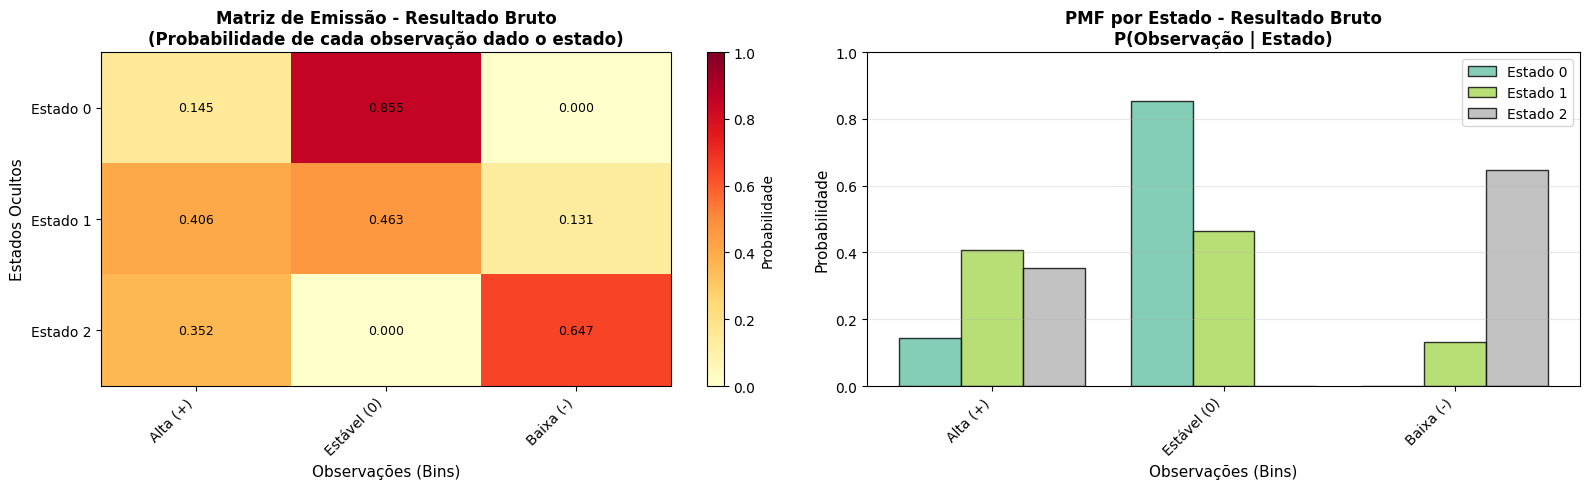


2. COMPARAÇÃO DE PMFs DE MÚLTIPLOS INDICADORES


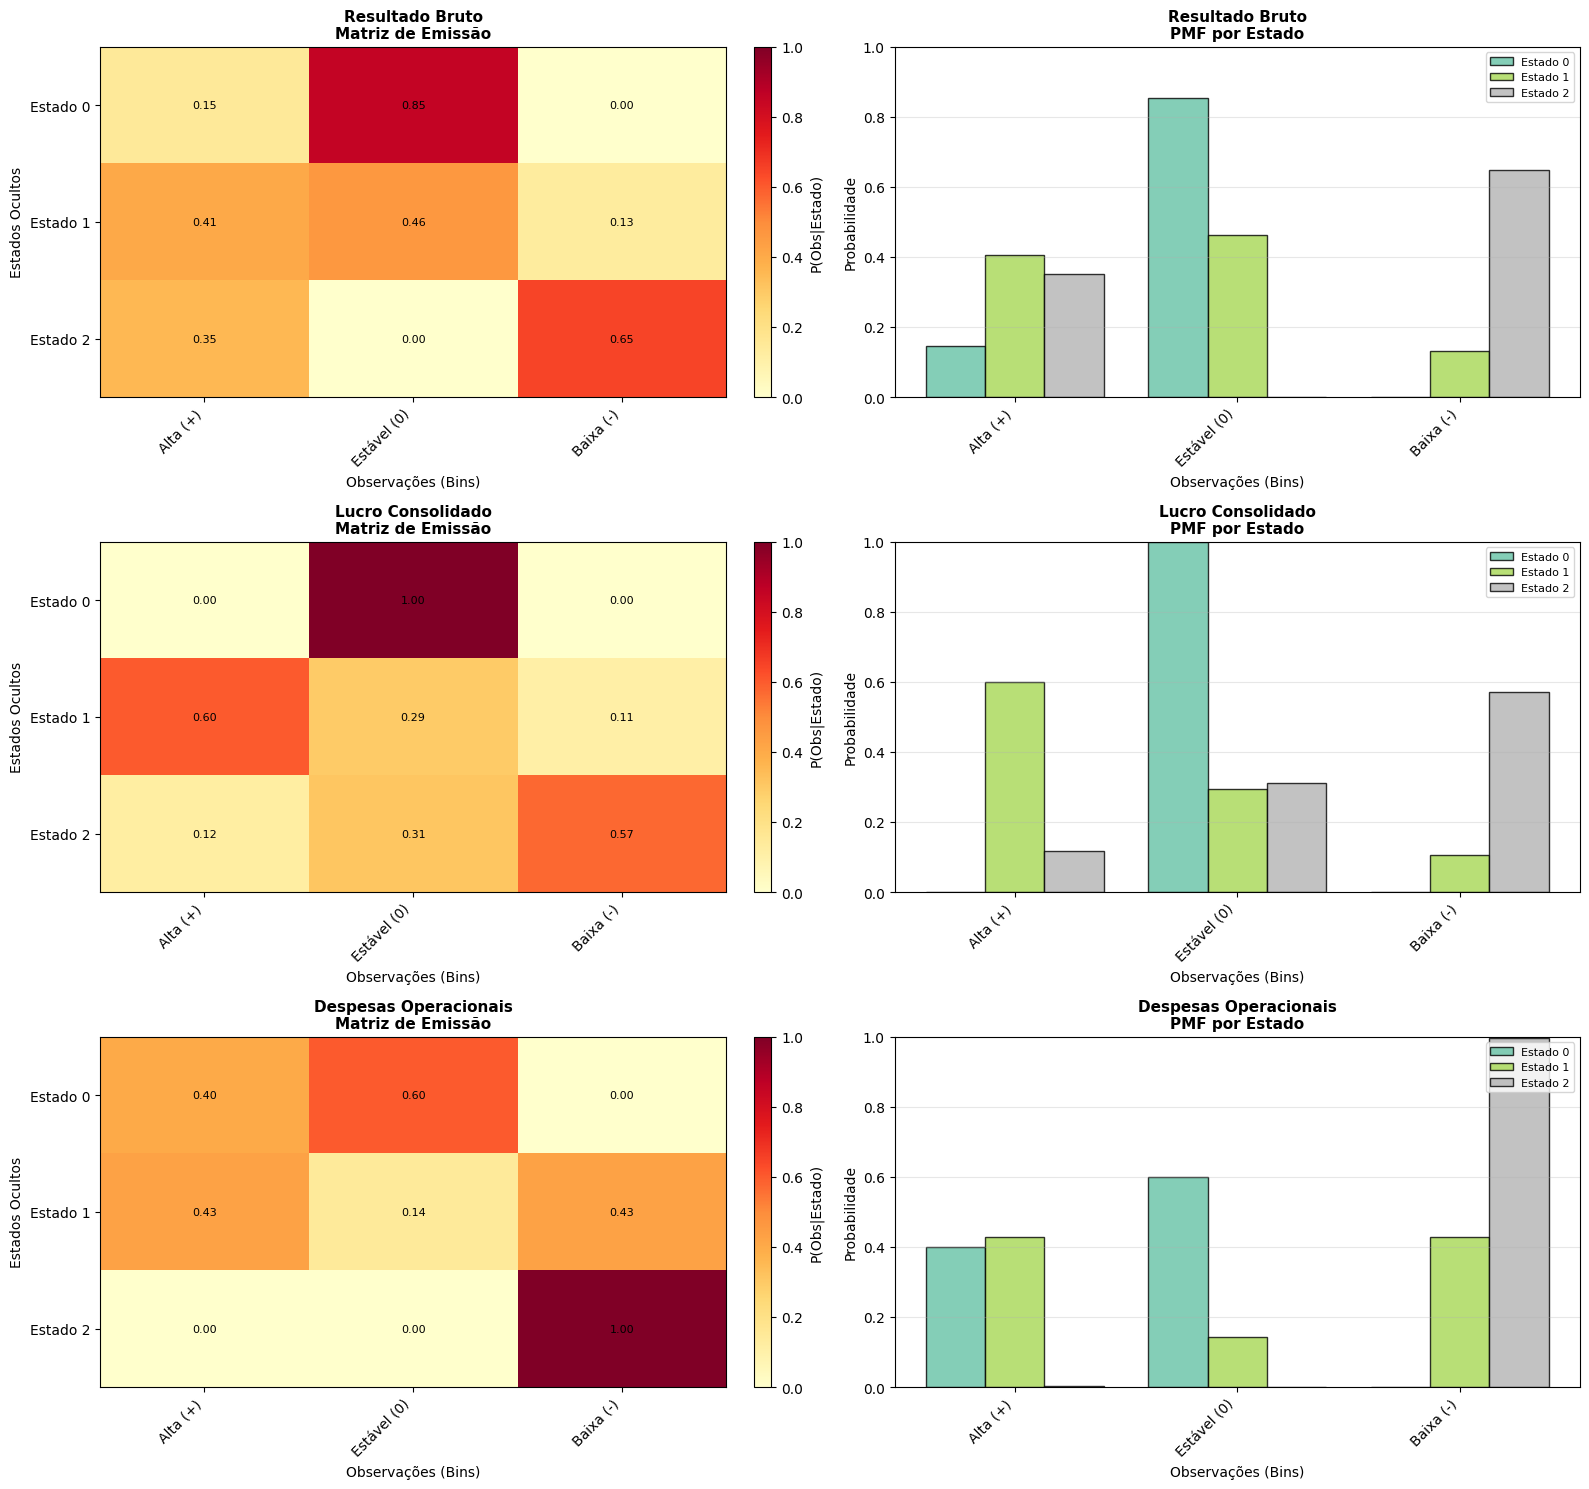


3. COMPARAÇÃO DO ESTADO 0 ENTRE INDICADORES


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (3,).

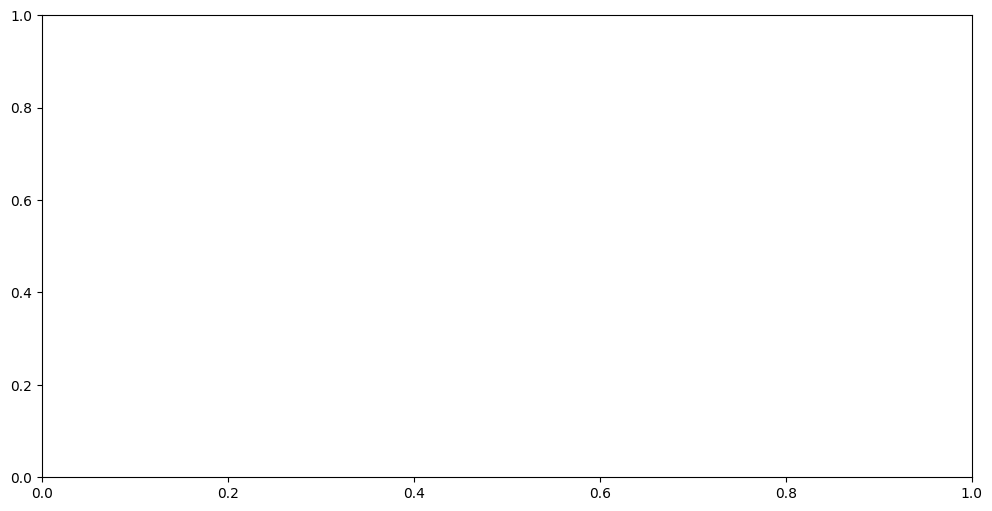

In [92]:
# Supondo que você já tenha treinado os modelos com analisar_multiplos_indicadores_hmm
# resultados_hmm = analisar_multiplos_indicadores_hmm(...)

# 1. Visualizar PMF de um indicador específico
print("=" * 70)
print("1. PMF DE UM INDICADOR ESPECÍFICO")
print("=" * 70)
plotar_pmf_individual(
    modelo=resultados_hmm['Resultado Bruto']['modelo'],
    nome_indicador='Resultado Bruto',
    n_bins=3,
    n_estados=3
)

# 2. Comparar PMFs de todos os indicadores lado a lado
print("\n" + "=" * 70)
print("2. COMPARAÇÃO DE PMFs DE MÚLTIPLOS INDICADORES")
print("=" * 70)
plotar_pmf_comparacao_multiplos(
    resultados=resultados_hmm,
    n_bins=3,
    n_estados=3
)

# 3. Comparar PMF de um estado específico entre indicadores
print("\n" + "=" * 70)
print("3. COMPARAÇÃO DO ESTADO 0 ENTRE INDICADORES")
print("=" * 70)
plotar_pmf_estado_especifico(
    resultados=resultados_hmm,
    estado=1,
    n_bins=4
)

# 4. Resumo textual com interpretação
resumo_pmf_textual(
    resultados=resultados_hmm,
    n_bins=3
)